In [44]:
# Libraries
import pandas as pd
import holidays
import pycountry
import openpyxl
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

<h1
style="
font-weight:bold;
color:#ffffff;
border-bottom:3px solid #4CAF50;
padding-bottom:8px;
">
Table of Contents
</h1>

* [1. Theoretical Framework](#theoretical-framework)
    * [1.1. Introduction](#theoretical-framework-introduction)
    * [1.2. Problem Statement](#theoretical-framework-problem-statement)
    * [1.3. Conceptual Framework](#theoretical-framework-conceptual-framework)
    * [1.4. Selection Criteria](#theoretical-framework-selection-criteria)
        * [1.4.1. Job Market Accessibility & Growth Index](#theoretical-framework-selection-criteria-job-market-accessibility-and-growth-index)
        * [1.4.2. Work Conditions & Benefits Index](#theoretical-framework-selection-criteria-work-conditions-and-benefits-index)
        * [1.4.3. Living Reality & Social Environment Index](#theoretical-framework-selection-criteria-living-reality-and-social-environment-index)
* [2. Data Selection](#data-selection)
    * [2.1. Job Market Accessibility & Growth Data](#data-selection-job-market-accessibility-and-growth-data)
    * [2.2. Work Conditions & Benefits Data](#data-selection-work-conditions-and-benefits-data)
    * [2.3. Living Reality & Social Environment Data](#data-selection-living-reality-and-social-environment-data)
* [3. Imputation of Missing Data](#imputation-of-missing-data)
    * [3.1. Data Quality & Missing Value Inspection](#imputation-of-missing-data-data-quality-and-missing-values)
        * [3.1.1. Dataset Inspection](#imputation-of-missing-data-data-quality-and-missing-values-dataset-inspection)
        * [3.1.2. Duplicate Record Inspection](#imputation-of-missing-data-data-quality-and-missing-values-duplicate-record-inspection)
        * [3.1.3. Minimum, Maximum & Logical Value Inspection](#imputation-of-missing-data-data-quality-and-missing-values-minimum-maximum-and-logical-value-inspection)
        * [3.1.4. Data Type & Numeric Conversion Inspection](#imputation-of-missing-data-data-quality-and-missing-values-data-type-and-numeric-conversion-inspection)
        * [3.1.5. Labour Market Dataset Findings](#imputation-of-missing-data-data-quality-and-missing-values-labour-market-dataset-findings)
        * [3.1.6. Work Conditions Dataset Findings](#imputation-of-missing-data-data-quality-and-missing-values-work-conditions-dataset-findings)
        * [3.1.7. Cost of Living Dataset Findings](#imputation-of-missing-data-data-quality-and-missing-values-cost-of-living-dataset-findings)
        * [3.1.8. World Happiness Dataset Findings](#imputation-of-missing-data-data-quality-and-missing-values-world-happiness-dataset-findings)
        * [3.1.9. Summary of Findings](#imputation-of-missing-data-data-quality-and-missing-values-summary-of-findings)
    * [3.2. Imputation Strategy](#imputation-of-missing-data-imputation-strategy)
        * [3.2.1. Labour-Market Dataset Imputation](#imputation-of-missing-data-imputation-strategy-labour-market-dataset-imputation)
        * [3.2.2. Cost of Living Dataset Restructuring](#imputation-of-missing-data-imputation-strategy-cost-of-living-dataset-restructuring)
        * [3.2.2. World Happiness Dataset Handling](#imputation-of-missing-data-imputation-strategy-world-happiness-dataset-handling)
    * [3.3. Post-Imputation Validation & Missing Value Verification](#imputation-of-missing-data-post-imputation-validation-and-missing-value-verification)
        * [3.3.1 Remaining Missing Values Check](#imputation-of-missing-data-post-imputation-validation-and-missing-value-verification-remaining-missing-values-check)
        * [3.3.2 Visual Validation of Missing Values](#imputation-of-missing-data-post-imputation-validation-and-missing-value-verification-visual-validation-of-missing-values)
    * [3.4. Interpretation of Outliers](#imputation-of-missing-data-interpretation-of-outliers)
        * [3.4.1 Job Market Accessibility & Growth Indicators](#imputation-of-missing-data-interpretation-of-outliers-job-market-accessibility-and-growth-indicators)
        * [3.4.2 Work Conditions & Benefits Indicators](#imputation-of-missing-data-interpretation-of-outliers-work-conditions-and-benefits-indicators)
        * [3.4.3 Living Reality & Social Environment Indicators](#imputation-of-missing-data-interpretation-of-outliers-living-reality-and-social-environment-indicators)
* [4. Multivariate Analysis](#multivariate-analysis)
    * [4.0. Preparing Thematic Analysis Dataframes](#multivariate-analysis-preparing-thematic-analysis-dataframes)
    * [4.1. Correlation Analysis](#multivariate-analysis-correlation-analysis)
        * [4.1.1. Job Market Correlation Analysis](#multivariate-analysis-correlation-analysis-job-market-correlation-analysis)
        * [4.1.2. Work Conditions Correlation Analysis](#multivariate-analysis-correlation-analysis-work-conditions-correlation-analysis)
        * [4.1.3. Living Reality Correlation Analysis](#multivariate-analysis-correlation-analysis-living-reality-correlation-analysis)
    * [4.2. Variance Inflation Factor (VIF) Analysis](#multivariate-analysis-variance-inflation-factor-vif-analysis)
        * [4.2.1. Job Market VIF Analysis](#multivariate-analysis-variance-inflation-factor-vif-analysis-job-market-vif-analysis)
        * [4.2.2. Work Conditions VIF Analysis](#multivariate-analysis-variance-inflation-factor-vif-analysis-work-conditions-vif-analysis)
        * [4.2.3. Living Reality VIF Analysis](#multivariate-analysis-variance-inflation-factor-vif-analysis-living-reality-vif-analysis)
    * [4.3. Principal Component Analysis (PCA)](#multivariate-analysis-principal-component-analysis-pca)
        * [4.3.1. Job Market PCA](#multivariate-analysis-principal-component-analysis-pca-job-market-pca)
        * [4.3.2. Work Conditions PCA](#multivariate-analysis-principal-component-analysis-pca-work-conditions-pca)
        * [4.3.3. Living Reality PCA](#multivariate-analysis-principal-component-analysis-pca-living-reality-pca)
    * [4.4. Cluster Analysis](#multivariate-analysis-cluster-analysis)
    * [4.5. Multivariate Analysis Summary](#multivariate-analysis-summary)

<div style="
background-color:#1e1e1e;
border-left:5px solid #4CAF50;
padding:10px;
margin:10px 0;
">

<b>Key Objective:</b>  
Develop the International Career Attractiveness Index (ICAI).

</div>

<h1 id="theoretical-framework" 
style="
font-weight:bold;
color:#ffffff;
border-bottom:3px solid #4CAF50;
padding-bottom:8px;
">
1. Theoretical Framework
</h1>

## **1.1. Introduction** <a class="anchor" id="theoretical-framework-introduction"></a>
In an increasingly globalised world, many individuals seek to build careers outside their home countries. However, choosing the most suitable country for career development is a complex decision that involves multiple factors beyond just salary.  

While some countries may offer high wages, they may also have high living costs, limited work-life balance, or restricted access for international workers.  

This project aims to develop a composite indicator, named the International Career Attractiveness Index (ICAI), which evaluates how favourable a country is for career development from an international perspective.  

The index provides a single score that allows for comparison between countries by combining multiple dimensions of career and living conditions.  

---
## **1.2. Problem Statement** <a class="anchor" id="theoretical-framework-problem-statement"></a>
Existing indices such as the [UN Development Programme Human Development Index (HDI)](https://hdr.undp.org/data-center/human-development-index#/indicies/HDI) or global competitiveness rankings provide useful insights into general development or economic performance, but they do not specifically address the real experience of an individual pursuing a career abroad.

This project addresses that gap by focusing on three key stages of an international career journey:  

- Entering the job market  
- Experiencing working conditions and benefits  
- Sustaining a lifestyle outside of work  

By structuring the index in this way, it reflects a more realistic and practical perspective on career decision-making for individuals considering working overseas.

---
## **1.3. Conceptual Framework** <a class="anchor" id="theoretical-framework-conceptual-framework"></a>
The International Career Attractiveness Index (ICAI) is designed as a multidimensional composite indicator, combining three sub-indices derived from three separate datasets. Each sub-index represents a distinct but interconnected dimension of working abroad:

- Job Market Accessibility & Growth Index  
Measures how easy it is for an individual to enter and progress within a country’s labour market.  

- Work Conditions & Benefits Index  
Evaluates the quality of employment once a job has been secured, focusing on work-life balance and employee benefits.  

- Living Reality & Social Environment Index  
Captures the cost and quality of life, ensuring that income is evaluated in the context of actual living conditions.  

These three sub-indices are combined to form the final ICAI score, ensuring that the index reflects both economic opportunity and real-world living conditions.

---
## **1.4. Selection Criteria** <a class="anchor" id="theoretical-framework-selection-criteria"></a>
To construct a meaningful composite indicator, variables are selected based on the following criteria:

- Relevance: Each variable must directly relate to the experience of working overseas  
- Comparability: Data must be available across multiple countries, with the same year of 2023 available
- Measurability: Variables must be quantitative and suitable for analysis
- Data Availability: Reliable and recent datasets must be accessible

The datasets used in this project are sourced from publicly available and reputable sources, including the World Bank, International Labour Organization, and global cost of living and happiness datasets.  

These sources provide consistent and comparable data across countries, making them appropriate for constructing a composite index.  

---
### **1.4.1. Job Market Accessibility & Growth Index** <a class="anchor" id="theoretical-framework-selection-criteria-job-market-accessibility-and-growth-index"></a>
This sub-index is constructed using data from the World Bank, focusing on labour market conditions and economic opportunity. The variables include:

- Unemployment rate (% of total labour force)
- Employment-to-population ratio (%)
- GDP per capita (proxy for income level)
- Labour force participation rate (%)
- Population growth (%)

These variables represent both input conditions (labour supply and participation) and output conditions (employment and income), providing a comprehensive view of job accessibility and growth potential.

---
### **1.4.2. Work Conditions & Benefits Index** <a class="anchor" id="theoretical-framework-selection-criteria-work-conditions-and-benefits-index"></a>
This sub-index evaluates the quality of working life using datasets related to labour conditions and benefits. The variables include:

- Public holidays + Paid annual leave
- Average hours worked per week

These variables reflect the process of employment, focusing on how work is experienced rather than simply accessed. This is important for assessing long-term sustainability and overall job satisfaction.

---
### **1.4.3. Living Reality & Social Environment Index** <a class="anchor" id="theoretical-framework-selection-criteria-living-reality-and-social-environment-index"></a>
This sub-index captures the real-world impact of working in a country using cost of living and well-being datasets. The variables include:

- Cost of living index
- Happiness score

These variables represent the outcomes of employment, ensuring that higher income is considered alongside living expenses and overall quality of life.

<h1 id="data-selection" 
style="
font-weight:bold;
color:#ffffff;
border-bottom:3px solid #4CAF50;
padding-bottom:8px;
">
2. Data Selection
</h1>

As discussed within the theoretical framework, the International Career Attractiveness Index (ICAI) aims to evaluate the attractiveness of countries for career development using multiple economic, employment, social, and quality-of-life indicators.  

To further emphasise this multidimensional approach, the data selection stage focuses on obtaining measurable and internationally comparable datasets capable of representing the core dimensions identified previously. These datasets were selected based on:

<ul>
<li>Relevance to career attractiveness</li>
<li>Availability of international country-level data</li>
<li>Consistency across countries</li>
<li>Recentness of the data</li>
<li>Suitability for multivariate analysis and composite index construction</li>
</ul>

Most datasets used within this project originate from internationally recognised organisations such as the World Bank, International Labour Organization (ILO), and the World Happiness Report, helping improve the reliability and credibility of the index.

To maintain temporal consistency, the majority of variables selected use data from 2023, with a small number of datasets using the most recent available year where 2023 data was unavailable.

Additionally, several preprocessing operations were required before integration into the ICAI dataset, including:

<ul>
<li>Column extraction and filtering</li>
<li>Country name standardisation</li>
<li>Datatype conversion</li>
<li>Renaming variables for readability</li>
<li>Handling invalid or missing numeric values</li>
</ul>

These preprocessing steps ensure that all datasets can later be merged into a unified dataframe suitable for imputation, multivariate analysis, normalisation, weighting, and aggregation.

---


<h2 id="data-selection-job-market-accessibility-and-growth-data"
style="
color:#ffffff;
border-bottom:2px solid #555;
padding-bottom:5px;">
2.1 Job Market Accessibility & Growth Data
</h2>

As identified within the conceptual framework, career attractiveness is strongly influenced by employment accessibility, labour market participation, and economic opportunity. To represent this dimension quantitatively, multiple labour-market and economic indicators were selected.

The following datasets were included:

| Indicator | Purpose | Source |
|---|---|---|
| Employment-to-population ratio | Measures employment accessibility | <a href="https://data.worldbank.org/indicator/SL.EMP.TOTL.SP.ZS" target="_blank">World Bank</a> |
| Unemployment rate | Measures labour market difficulty | <a href="https://data.worldbank.org/indicator/SL.UEM.TOTL.ZS" target="_blank">World Bank</a> |
| GDP per capita | Represents economic prosperity | <a href="https://data.worldbank.org/indicator/NY.GDP.PCAP.CD" target="_blank">World Bank</a> |
| Labour force participation rate | Measures workforce engagement | <a href="https://data.worldbank.org/indicator/SL.TLF.CACT.ZS" target="_blank">World Bank</a> |
| Population growth | Provides demographic and economic context | <a href="https://data.worldbank.org/indicator/SP.POP.GROW" target="_blank">World Bank</a> |

The datasets were sourced primarily from the World Bank due to its extensive international coverage, structured reporting format, and consistency across countries.

Within the notebook, only the required columns were extracted from each dataset, specifically:

<ul>
<li>Country Name</li>
<li>Country Code</li>
<li>2023 indicator value</li>
</ul>

The indicators were then renamed into clearer variable names such as:

<ul>
<li><code>Employment_2023</code></li>
<li><code>GDP_2023</code></li>
<li><code>Labour_2023</code></li>
<li><code>Population_2023</code></li>
<li><code>Unemployment_2023</code></li>
</ul>

Numeric conversion was also applied using <code>pd.to_numeric(..., errors="coerce")</code> to ensure invalid values were automatically converted into NaN values for later handling during the imputation stage.

At this stage, indicators were intentionally retained even where conceptual overlap may exist. For example, employment rate and labour force participation rate may exhibit multicollinearity due to measuring related labour market behaviour. This relationship will be formally investigated later during the multivariate analysis section using correlation analysis and variance inflation factor (VIF) testing.

---

In [3]:
employment = pd.read_csv("../data/Job_Market_Access_and_Growth/Employment.csv", skiprows=4)
employment = employment[["Country Name", "Country Code", "2023"]]                               # Keep only relevant columns
employment = employment.rename(columns={"2023": "Employment_2023"})                             # Rename for clarity
employment["Employment_2023"] = pd.to_numeric(employment["Employment_2023"], errors="coerce")   # Convert to numeric, coercing errors to NaN                                                                       # Display the first few rows to verify the data

#--------------------------------------------------------------------------------------------------------#

gdp = pd.read_csv("../data/Job_Market_Access_and_Growth/GDP_Per_Capita.csv", skiprows=4)
gdp = gdp[["Country Name", "Country Code", "2023"]]                 # Keep only relevant columns
gdp = gdp.rename(columns={"2023": "GDP_2023"})                      # Rename for clarity
gdp["GDP_2023"] = pd.to_numeric(gdp["GDP_2023"], errors="coerce")   # Convert to numeric, coercing errors to NaN

#--------------------------------------------------------------------------------------------------------#

labour = pd.read_csv("../data/Job_Market_Access_and_Growth/Labour_Force_Participation_Rate.csv", skiprows=4)
labour = labour[["Country Name", "Country Code", "2023"]]                       # Keep only relevant columns
labour = labour.rename(columns={"2023": "Labour_2023"})                         # Rename for clarity
labour["Labour_2023"] = pd.to_numeric(labour["Labour_2023"], errors="coerce")   # Convert to numeric, coercing errors to NaN

#--------------------------------------------------------------------------------------------------------#

population = pd.read_csv("../data/Job_Market_Access_and_Growth/Population_Growth.csv", skiprows=4)
population = population[["Country Name", "Country Code", "2023"]]                               # Keep only relevant columns
population = population.rename(columns={"2023": "Population_2023"})                             # Rename for clarity
population["Population_2023"] = pd.to_numeric(population["Population_2023"], errors="coerce")   # Convert to numeric, coercing errors to NaN

#--------------------------------------------------------------------------------------------------------#

unemployment = pd.read_csv("../data/Job_Market_Access_and_Growth/Unemployment.csv", skiprows=4)
unemployment = unemployment[["Country Name", "Country Code", "2023"]]                                   # Keep only relevant columns
unemployment = unemployment.rename(columns={"2023": "Unemployment_2023"})                               # Rename for clarity
unemployment["Unemployment_2023"] = pd.to_numeric(unemployment["Unemployment_2023"], errors="coerce")   # Convert to numeric, coercing errors to NaN

In [4]:
display(Markdown("### Employment Dataset Sample"))
display(employment.head(5))

display(Markdown("### GDP Per Capita Dataset Sample"))
display(gdp.head(5))

display(Markdown("### Labour Force Participation Dataset Sample"))
display(labour.head(5))

display(Markdown("### Population Growth Dataset Sample"))
display(population.head(5))

display(Markdown("### Unemployment Dataset Sample"))
display(unemployment.head(5))

### Employment Dataset Sample

,Country Name,Country Code,Employment_2023
0,Aruba,ABW,NaN
1,Africa Eastern and Southern,AFE,63.596635
2,Afghanistan,AFG,32.323000
3,Africa Western and Central,AFW,70.123283
4,Angola,AGO,64.369000


### GDP Per Capita Dataset Sample

,Country Name,Country Code,GDP_2023
0,Aruba,ABW,35718.753119
1,Africa Eastern and Southern,AFE,1571.449189
2,Afghanistan,AFG,413.757895
3,Africa Western and Central,AFW,1841.855064
4,Angola,AGO,2916.136633


### Labour Force Participation Dataset Sample

,Country Name,Country Code,Labour_2023
0,Aruba,ABW,NaN
1,Africa Eastern and Southern,AFE,68.884368
2,Afghanistan,AFG,37.588000
3,Africa Western and Central,AFW,72.441989
4,Angola,AGO,74.892000


### Population Growth Dataset Sample

,Country Name,Country Code,Population_2023
0,Aruba,ABW,0.045652
1,Africa Eastern and Southern,AFE,2.519167
2,Afghanistan,AFG,2.135594
3,Africa Western and Central,AFW,2.386204
4,Angola,AGO,3.080655


### Unemployment Dataset Sample

,Country Name,Country Code,Unemployment_2023
0,Aruba,ABW,NaN
1,Africa Eastern and Southern,AFE,7.676548
2,Afghanistan,AFG,14.008000
3,Africa Western and Central,AFW,3.200801
4,Angola,AGO,14.051000


<h2 id="data-selection-work-conditions-and-benefits-data"
style="
color:#ffffff;
border-bottom:2px solid #555;
padding-bottom:5px;">
2.2 Work Conditions & Benefits Data
</h2>

To further develop the ICAI beyond purely economic measures, work-life balance and employee welfare indicators were incorporated into the index. This reflects the understanding established earlier that career attractiveness is influenced not only by employment availability, but also by working conditions and quality of employment.

The following indicators were selected:

| Indicator | Purpose | Source |
|---|---|---|
| Average hours worked per week | Measures work intensity | <a href="https://ilostat.ilo.org/topics/working-time/" target="_blank">International Labour Organization (ILO)</a> |
| Paid annual leave | Measures employee leave entitlement | <a href="https://www.voronoiapp.com/work/The-Countries-With-the-Most-and-Least-Paid-Leave-in-2025-6025#dataset" target="_blank">Voronoi - Paid Leave Dataset</a> |
| Paid public holidays | Measures national leave benefits | <a href="https://www.voronoiapp.com/work/The-Countries-With-the-Most-and-Least-Paid-Leave-in-2025-6025#dataset" target="_blank">Voronoi - Paid Leave Dataset</a> |
| Total paid time off | Represents overall leave benefits | Derived from paid leave and public holiday datasets |

The average working hours dataset was sourced from the International Labour Organization (ILO), while paid leave datasets were obtained from publicly available international labour statistics sources.

Additional datasets and APIs relating to public holidays were researched during the development process, including:

<ul>
<li><a href="https://learn.microsoft.com/en-us/azure/open-datasets/dataset-public-holidays?tabs=azureml-opendatasets" target="_blank">Microsoft Azure Open Public Holidays Dataset</a></li>
<li><a href="https://pypi.org/project/holidays/" target="_blank">Python Holidays Package</a></li>
</ul>

However, these were ultimately not used within the final ICAI implementation due to sufficient coverage already being available within the selected paid leave dataset.

Several preprocessing steps were required within the notebook:

<ul>
<li>Extraction of relevant columns only</li>
<li>Renaming columns for readability</li>
<li>Conversion of values into numeric format</li>
<li>Creation of derived indicators</li>
</ul>

For example, the following columns were extracted and renamed:

<ul>
<li><code>PAID ANNUAL LEAVE DAYS -> Paid_Annual_Leave</code></li>
<li><code>PAID PUBLIC HOLIDAYS -> Paid_Public_Holidays</code></li>
<li><code>TOTAL PAID TIME OFF -> Total_Paid_Time_Off</code></li>
</ul>

Numeric conversion was then applied using <code>pd.to_numeric(..., errors="coerce")</code> to ensure data consistency and allow invalid values to be converted into NaN values for later handling during the imputation stage.

A derived variable named <code>Total_Paid_Time_Off</code> was created by combining paid annual leave and paid public holidays. This was done to provide a broader representation of employee benefits and work-life balance.

These indicators contribute an important social dimension to the ICAI, helping distinguish countries with stronger worker protections and healthier work environments.

---

In [5]:
avg_hrs = pd.read_csv("../data/Work_Conditions_And_Benefits/Avg_Hrs_Worked_Per_Week.csv")
avg_hrs = avg_hrs[["ref_area.label", "time", "obs_value"]]                                                          # Keep only relevant columns
avg_hrs = avg_hrs.rename(columns={                                                                                  # Rename for clarity
    "ref_area.label": "Country Name",
    "obs_value": "Avg_Hours_Worked_Most_Recent"
})
avg_hrs["Avg_Hours_Worked_Most_Recent"] = pd.to_numeric(avg_hrs["Avg_Hours_Worked_Most_Recent"], errors="coerce")   # Convert to numeric, coercing errors to NaN

#--------------------------------------------------------------------------------------------------------#

paid_time_off = pd.read_csv("../data/Work_Conditions_And_Benefits/Paid_Time_Off_2025.csv")
paid_time_off = paid_time_off[[                                                     # Keep only relevant columns
    "COUNTRY",
    "PAID ANNUAL LEAVE DAYS",
    "PAID PUBLIC HOLIDAYS",
    "TOTAL PAID TIME OFF"
]]
paid_time_off = paid_time_off.rename(columns={                                      # Rename for clarity
    "COUNTRY": "Country Name",
    "PAID ANNUAL LEAVE DAYS": "Paid_Annual_Leave",
    "PAID PUBLIC HOLIDAYS": "Paid_Public_Holidays",
    "TOTAL PAID TIME OFF": "Total_Paid_Time_Off"
})
cols = ["Paid_Annual_Leave", "Paid_Public_Holidays", "Total_Paid_Time_Off"]
paid_time_off[cols] = paid_time_off[cols].apply(pd.to_numeric, errors="coerce")     # Convert to numeric, coercing errors to NaN

In [6]:
display(Markdown("### Average Hours Worked Dataset Sample"))
display(avg_hrs.head(5))

display(Markdown("### Paid Time Off Dataset Sample"))
display(paid_time_off.head(5))

### Average Hours Worked Dataset Sample

,Country Name,time,Avg_Hours_Worked_Most_Recent
0,Aruba,2010,39.43
1,Afghanistan,2021,39.60
2,Angola,2025,43.29
3,Albania,2024,41.33
4,United Arab Emirates,2024,50.82


### Paid Time Off Dataset Sample

,Country Name,Paid_Annual_Leave,Paid_Public_Holidays,Total_Paid_Time_Off
0,Afghanistan,20.0,15,35.0
1,Albania,22.0,14,36.0
2,Algeria,22.0,11,33.0
3,Andorra,22.0,14,36.0
4,Angola,22.0,12,34.0


<h2 id="data-selection-living-reality-and-social-environment-data"
style="
color:#ffffff;
border-bottom:2px solid #555;
padding-bottom:5px;">
2.3 Living Reality & Social Environment Data
</h2>

As addressed previously within the theoretical framework, economic opportunity alone does not fully determine career attractiveness. The practical living experience associated with relocating and working within a country must also be considered.

To represent this dimension, datasets relating to cost of living, income, and wellbeing were selected.

The following indicators were included:

| Indicator | Purpose | Source |
|---|---|---|
| Food cost index | Measures affordability of essentials | <a href="https://www.kaggle.com/datasets/mvieira101/global-cost-of-living" target="_blank">Global Cost of Living Dataset (Kaggle)</a> |
| Transport & utilities index | Measures infrastructure-related living expenses | <a href="https://www.kaggle.com/datasets/mvieira101/global-cost-of-living" target="_blank">Global Cost of Living Dataset (Kaggle)</a> |
| Housing cost index | Measures accommodation affordability | <a href="https://www.kaggle.com/datasets/mvieira101/global-cost-of-living" target="_blank">Global Cost of Living Dataset (Kaggle)</a> |
| Income | Represents earning potential | <a href="https://www.kaggle.com/datasets/mvieira101/global-cost-of-living" target="_blank">Global Cost of Living Dataset (Kaggle)</a> |
| Happiness score | Measures societal wellbeing | <a href="https://www.worldhappiness.report/data-sharing/" target="_blank">World Happiness Report</a> |

The cost-of-living dataset required substantial preprocessing and feature engineering. Rather than relying on a single overall value, several sub-indices were constructed using grouped averages from multiple underlying variables.

For example:

<ul>
<li>Food cost index was calculated using food and grocery-related variables</li>
<li>Transport & utilities index combined transport and utility costs</li>
<li>Housing cost index used rental-related variables</li>
</ul>

This approach allows the ICAI to capture more specific aspects of living affordability rather than oversimplifying cost of living into a single measure.

Within the notebook, grouped averages were calculated using multiple dataset columns to create more interpretable sub-indices:

<ul>
<li><code>Food_Cost_Index</code></li>
<li><code>Transport_Utilities_Index</code></li>
<li><code>Housing_Cost_Index</code></li>
<li><code>Income</code></li>
</ul>

The dataset was also reduced to only the required variables to improve clarity and reduce unnecessary complexity during later stages of analysis.

Income data was retained separately to allow later comparison between salary potential and living expenses, helping evaluate practical affordability rather than income alone.

The World Happiness Report dataset was additionally incorporated to introduce a broader societal wellbeing perspective into the ICAI. However, not all variables from the original dataset were retained. Several explanatory decomposition variables such as confidence interval whiskers and GDP contribution metrics were excluded to reduce redundancy and minimise potential multicollinearity with existing economic indicators already included elsewhere within the ICAI framework.

The final happiness-related variables retained focused primarily on:
<ul>
<li>Overall happiness score</li>
<li>Social support</li>
<li>Healthy life expectancy</li>
<li>Freedom to make life choices</li>
<li>Perceptions of corruption</li>
</ul>

These variables were considered more directly relevant to long-term quality of life and societal attractiveness for international career development.

Together, these datasets help ensure the ICAI captures both professional opportunity and practical quality-of-life considerations.

---

In [7]:
cost_of_living = pd.read_csv("../data/Living_Reality_And_Social_Environment/Cost_Of_Living.csv")

cost_of_living = cost_of_living.rename(columns={"country": "Country Name"})

# Daily Living Cost (Food + essentials)
# x1 -> x8 (restaurant/basic consumption)
# x9 -> x21 (groceries)
cost_of_living["Food_Cost_Index"] = cost_of_living[[f"x{i}" for i in range(1, 22)]].mean(axis=1)

# Transport & Utilities Cost
# x28 -> x33 (transport)
# x36, x38 (utilities + internet)
cost_of_living["Transport_Utilities_Index"] = cost_of_living[[f"x{i}" for i in range(28, 34)] + ["x36", "x38"]].mean(axis=1)

# Housing Cost
# x48 -> x51 (rent)
cost_of_living["Housing_Cost_Index"] = cost_of_living[["x48", "x49", "x50", "x51"]].mean(axis=1)

# Income
# x54 -> Average Monthly Net Salary
cost_of_living["Income"] = pd.to_numeric(cost_of_living["x54"], errors="coerce")

cost_of_living = cost_of_living[[
    "Country Name",
    "Food_Cost_Index",
    "Transport_Utilities_Index",
    "Housing_Cost_Index",
    "Income"
]]

cost_of_living.head()

#--------------------------------------------------------------------------------------------------------#

happiness = pd.read_excel("../data/Living_Reality_And_Social_Environment/World_Happiness_Report.xlsx")

happiness = happiness[[
    "Rank",
    "Country name",
    "Life evaluation (3-year average)",
    "Explained by: Social support",
    "Explained by: Healthy life expectancy",
    "Explained by: Freedom to make life choices",
    "Explained by: Perceptions of corruption"
]]

happiness = happiness.rename(columns={
    "Rank" : "Rank",
    "Country name": "Country Name",
    "Life evaluation (3-year average)": "Happiness_Score",
    "Explained by: Social support": "Social_Support",
    "Explained by: Healthy life expectancy": "Healthy_Life_Expectancy",
    "Explained by: Freedom to make life choices": "Freedom",
    "Explained by: Perceptions of corruption": "Corruption_Perception"
})

In [8]:
display(Markdown("### Cost of Living Dataset Sample"))
display(cost_of_living.head(5))

display(Markdown("### Happiness Dataset Sample"))
display(happiness.head(5))

### Cost of Living Dataset Sample

,Country Name,Food_Cost_Index,Transport_Utilities_Index,Housing_Cost_Index,Income
0,India,2.900952,10.09375,319.8075,586.35
1,China,5.479048,15.25875,1537.2925,1382.83
2,Indonesia,3.385238,15.58375,613.7650,483.19
3,Philippines,3.583810,19.03875,820.1275,419.02
4,South Korea,8.774762,31.87125,1424.5550,2672.23


### Happiness Dataset Sample

,Rank,Country Name,Happiness_Score,Social_Support,Healthy_Life_Expectancy,Freedom,Corruption_Perception
0,1,Finland,7.764,1.638,0.939,1.105,0.491
1,2,Iceland,7.540,1.720,0.996,1.105,0.187
2,3,Denmark,7.539,1.633,0.930,1.081,0.474
3,4,Costa Rica,7.439,1.483,0.739,1.101,0.122
4,5,Sweden,7.255,1.570,1.027,1.070,0.447


<h1 id="imputation-of-missing-data" 
style="
font-weight:bold;
color:#ffffff;
border-bottom:3px solid #4CAF50;
padding-bottom:8px;
">
3. Imputation of Missing Data
</h1>

As outlined within the specification, missing data must be addressed in order to produce complete and comparable datasets across all countries included within the International Career Attractiveness Index (ICAI). Since the project integrates multiple international datasets from different sources, some variables contained incomplete observations or unavailable country values.

Missing values may occur for several reasons, including:

<ul>
<li>Differences in international reporting standards</li>
<li>Unavailable country-level statistics</li>
<li>Differences in reporting years</li>
<li>Incomplete public datasets</li>
<li>Economic or political instability affecting data collection</li>
</ul>

Unlike a fully centralised data structure, the ICAI framework was intentionally designed around three distinct thematic datasets corresponding to the three major dimensions identified within the theoretical framework:

<ul>
<li>Job Market Accessibility & Growth</li>
<li>Work Conditions & Benefits</li>
<li>Living Reality & Social Environment</li>
</ul>

This structure allows each dimension to independently generate its own sub-index before later aggregation into the final ICAI score. As a result, missing-data handling was performed separately within each thematic dataframe rather than within a single unified dataset.

---

<h2 id="imputation-of-missing-data-data-quality-and-missing-values"
style="
color:#ffffff;
border-bottom:2px solid #555;
padding-bottom:5px;">
3.1 Data Quality & Missing Value Inspection
</h2>

Before performing imputation, a broader data-quality inspection was carried out across each dataset used within the ICAI framework.

Although this section focuses primarily on missing values, additional checks were also performed to identify:

<ul>
<li>Negative values</li>
<li>Duplicate records</li>
<li>Minimum and maximum ranges</li>
<li>Logical inconsistencies</li>
<li>Incorrect data types</li>
<li>Potential categorical-to-numerical conversion issues</li>
</ul>

This stage was necessary because a value may exist within a dataset while still being unsuitable for analysis if it is logically invalid. For example:

<ul>
<li>GDP per capita should not be negative</li>
<li>Employment and unemployment rates should remain within realistic percentage ranges</li>
<li>Paid leave values should not be negative</li>
<li>Cost-of-living indicators should remain positive</li>
</ul>

The inspection was therefore designed to identify both explicit missingness and broader data-quality concerns before later preprocessing stages.

---

<h3 id="imputation-of-missing-data-data-quality-and-missing-values-dataset-inspection"
style="
color:#dddddd;
padding-bottom:3px;">
3.1.1 Dataset Inspection
</h3>

The following datasets were inspected independently prior to the construction of the ICAI sub-indices:

<ul>
<li><code>employment</code></li>
<li><code>gdp</code></li>
<li><code>labour</code></li>
<li><code>population</code></li>
<li><code>unemployment</code></li>
<li><code>avg_hrs</code></li>
<li><code>paid_time_off</code></li>
<li><code>cost_of_living</code></li>
<li><code>happiness</code></li>
</ul>

Dataset-level missing values were initially identified using:

In [9]:
datasets = {
    "Employment": employment,
    "GDP": gdp,
    "Labour Force Participation": labour,
    "Population Growth": population,
    "Unemployment": unemployment,
    "Average Hours Worked": avg_hrs,
    "Paid Time Off": paid_time_off,
    "Cost of Living": cost_of_living,
    "Happiness": happiness
}

for name, df in datasets.items():
    print(f"\n{name}")
    print(df.isnull().sum())


for name, df in datasets.items():
    print(f"\n{name}")
    df.info()


Employment
Country Name        0
Country Code        0
Employment_2023    34
dtype: int64

GDP
Country Name     0
Country Code     0
GDP_2023        15
dtype: int64

Labour Force Participation
Country Name     0
Country Code     0
Labour_2023     34
dtype: int64

Population Growth
Country Name       0
Country Code       0
Population_2023    1
dtype: int64

Unemployment
Country Name          0
Country Code          0
Unemployment_2023    34
dtype: int64

Average Hours Worked
Country Name                    0
time                            0
Avg_Hours_Worked_Most_Recent    0
dtype: int64

Paid Time Off
Country Name            0
Paid_Annual_Leave       0
Paid_Public_Holidays    0
Total_Paid_Time_Off     0
dtype: int64

Cost of Living
Country Name                    0
Food_Cost_Index                87
Transport_Utilities_Index     178
Housing_Cost_Index           1074
Income                       1415
dtype: int64

Happiness
Rank                          0
Country Name                  0

These checks helped identify:

<ul>
<li>Non-null counts</li>
<li>Data types</li>
<li>Potentially incomplete variables</li>
<li>Columns requiring numeric conversion</li>
</ul>

---

<h3 id="imputation-of-missing-data-data-quality-and-missing-values-duplicate-record-inspection"
style="
color:#dddddd;
padding-bottom:3px;">
3.1.2 Duplicate Record Inspection
</h3>

Duplicate rows were inspected to determine whether repeated observations represented genuine duplication or valid structural repetition.

In [10]:
for name, df in datasets.items():
    print(f"\n{name}")
    print("Duplicate rows:", df.duplicated().sum())


Employment
Duplicate rows: 0

GDP
Duplicate rows: 0

Labour Force Participation
Duplicate rows: 0

Population Growth
Duplicate rows: 0

Unemployment
Duplicate rows: 0

Average Hours Worked
Duplicate rows: 0

Paid Time Off
Duplicate rows: 0

Cost of Living
Duplicate rows: 43

Happiness
Duplicate rows: 7


Country-level duplication was also inspected separately:

In [11]:
for name, df in datasets.items():
    print(f"\n{name}")

    if "Country Name" in df.columns:
        print(
            "Duplicate countries:",
            df["Country Name"].duplicated().sum()
        )


Employment
Duplicate countries: 0

GDP
Duplicate countries: 0

Labour Force Participation
Duplicate countries: 0

Population Growth
Duplicate countries: 0

Unemployment
Duplicate countries: 0

Average Hours Worked
Duplicate countries: 0

Paid Time Off
Duplicate countries: 0

Cost of Living
Duplicate countries: 4670

Happiness
Duplicate countries: 1948


This check was particularly important for the Cost of Living dataset because multiple rows represented different cities within the same country.

Therefore, duplicate country names within this dataset were expected and did not automatically indicate data-quality errors.

For example:

<ul>
<li>One country may contain multiple city observations</li>
<li>Each city may contain different living-cost values</li>
<li>Some cities may contain incomplete records</li>
</ul>

As a result, duplication within this dataset reflected structural granularity rather than accidental duplication.

---


<h3 id="imputation-of-missing-data-data-quality-and-missing-values-minimum-maximum-and-logical-value-inspection"
style="
color:#dddddd;
padding-bottom:3px;">
3.1.3 Minimum, Maximum & Logical Value Inspection
</h3>

Numeric ranges were inspected to determine whether values remained logically reasonable.

In [12]:
for name, df in datasets.items():
    print(f"\n{name}")

    numeric_df = df.select_dtypes(
        include=["float64", "int64"]
    )

    display(
        numeric_df.describe().T[
            ["min", "max", "mean", "50%"]
        ]
    )


Employment


,min,max,mean,50%
Employment_2023,21.328,87.437,57.216791,58.224674



GDP


,min,max,mean,50%
GDP_2023,250.627253,256799.788613,20172.185789,7802.824333



Labour Force Participation


...

,min,max,mean,50%
Paid_Annual_Leave,0.0,30.0,17.731551,20.0
Paid_Public_Holidays,0.0,23.0,12.171123,12.0
Total_Paid_Time_Off,0.0,46.0,29.902674,31.0



Cost of Living


,min,max,mean,50%
Food_Cost_Index,0.523333,38.5450,5.765018,5.422857
Transport_Utilities_Index,0.120000,81068.8050,51.951714,30.312976
Housing_Cost_Index,19.655000,16106.6675,876.937496,646.691250
Income,18.000000,12681.2600,1817.033501,1298.370000



Happiness


,min,max,mean,50%
Rank,1.000,158.000,76.190926,76.000000
Happiness_Score,1.364,7.856,5.465655,5.480000
Social_Support,0.000,1.840,1.096746,1.140119
Healthy_Life_Expectancy,0.000,1.238,0.553435,0.560500
Freedom,0.000,1.147,0.609465,0.602000
Corruption_Perception,0.000,0.587,0.144911,0.113000


This inspection was used to identify:

<ul>
<li>Extremely small or large values</li>
<li>Impossible negative values</li>
<li>Potential data-entry errors</li>
<li>Indicators requiring later outlier analysis</li>
</ul>

Negative values were then inspected separately:

In [13]:
for name, df in datasets.items():
    print(f"\n{name}")

    numeric_df = df.select_dtypes(
        include=["float64", "int64"]
    )

    negative_counts = (numeric_df < 0).sum()

    print(
        negative_counts[
            negative_counts > 0
        ]
    )


Employment
Series([], dtype: int64)

GDP
Series([], dtype: int64)

Labour Force Participation
Series([], dtype: int64)

Population Growth
Population_2023    41
dtype: int64

Unemployment
Series([], dtype: int64)

Average Hours Worked
Series([], dtype: int64)

Paid Time Off
Series([], dtype: int64)

Cost of Living
Series([], dtype: int64)

Happiness
Series([], dtype: int64)


Most variables were expected to remain non-negative.

However, population growth was treated differently because negative values are logically possible and may represent genuine population decline.

Additional logical validation checks were therefore performed:

In [14]:
logical_checks = {
    "Employment": {
        "df": employment,
        "non_negative": ["Employment_2023"],
        "percentage_0_100": ["Employment_2023"]
    },

    "GDP": {
        "df": gdp,
        "non_negative": ["GDP_2023"]
    },

    "Labour Force Participation": {
        "df": labour,
        "non_negative": ["Labour_2023"],
        "percentage_0_100": ["Labour_2023"]
    },

    "Population Growth": {
        "df": population,
        "allow_negative": ["Population_2023"]
    },

    "Unemployment": {
        "df": unemployment,
        "non_negative": ["Unemployment_2023"],
        "percentage_0_100": ["Unemployment_2023"]
    },

    "Average Hours Worked": {
        "df": avg_hrs,
        "non_negative": [
            "Avg_Hours_Worked_Most_Recent"
        ]
    },

    "Paid Time Off": {
        "df": paid_time_off,
        "non_negative": [
            "Paid_Annual_Leave",
            "Paid_Public_Holidays",
            "Total_Paid_Time_Off"
        ]
    },

    "Cost of Living": {
        "df": cost_of_living,
        "non_negative": [
            "Food_Cost_Index",
            "Transport_Utilities_Index",
            "Housing_Cost_Index",
            "Income"
        ]
    },

    "Happiness": {
        "df": happiness,
        "non_negative": [
            "Happiness_Score",
            "Social_Support",
            "Healthy_Life_Expectancy",
            "Freedom",
            "Corruption_Perception"
        ]
    }
}

for dataset_name, rules in logical_checks.items():

    df = rules["df"]

    print(f"\n{dataset_name}")

    for col in rules.get("non_negative", []):

        invalid = df[df[col] < 0]

        print(
            f"{col} negative values:",
            len(invalid)
        )

    for col in rules.get(
        "percentage_0_100",
        []
    ):

        invalid = df[
            (df[col] < 0) |
            (df[col] > 100)
        ]

        print(
            f"{col} outside 0-100 range:",
            len(invalid)
        )


Employment
Employment_2023 negative values: 0
Employment_2023 outside 0-100 range: 0

GDP
GDP_2023 negative values: 0

Labour Force Participation
Labour_2023 negative values: 0
Labour_2023 outside 0-100 range: 0

Population Growth

Unemployment
Unemployment_2023 negative values: 0
Unemployment_2023 outside 0-100 range: 0

Average Hours Worked
Avg_Hours_Worked_Most_Recent negative values: 0

Paid Time Off
Paid_Annual_Leave negative values: 0
Paid_Public_Holidays negative values: 0
Total_Paid_Time_Off negative values: 0

Cost of Living
Food_Cost_Index negative values: 0
Transport_Utilities_Index negative values: 0
Housing_Cost_Index negative values: 0
Income negative values: 0

Happiness
Happiness_Score negative values: 0
Social_Support negative values: 0
Healthy_Life_Expectancy negative values: 0
Freedom negative values: 0
Corruption_Perception negative values: 0


These checks confirmed that most datasets remained logically consistent.

GDP per capita exhibited extremely large maximum values, which was expected due to major economic differences between high-income and low-income countries.

Similarly, unemployment and population growth displayed wider variability because these indicators naturally fluctuate across countries and economic conditions.


---

<h3 if="imputation-of-missing-data-data-quality-and-missing-values-data-type-and-numeric-conversion-inspection"
style="
color:#dddddd;
padding-bottom:3px;">
3.1.4 Data Type & Numeric Conversion Inspection
</h3>

Categorical and non-numeric columns were also inspected:


In [15]:
for name, df in datasets.items():

    print(f"\n{name}")

    print(
        df.select_dtypes(
            include=["object", "string"]
        ).columns.tolist()
    )


Employment
['Country Name', 'Country Code']

GDP
['Country Name', 'Country Code']

Labour Force Participation
['Country Name', 'Country Code']

Population Growth
['Country Name', 'Country Code']

Unemployment
['Country Name', 'Country Code']

Average Hours Worked
['Country Name']

Paid Time Off
['Country Name']

Cost of Living
['Country Name']

Happiness
['Country Name']


Most categorical columns represented identifiers rather than analytical variables.

For example:

In [16]:
employment["Employment_2023"] = pd.to_numeric(
    employment["Employment_2023"],
    errors="coerce"
)

The same approach was applied to additional numeric indicators where necessary.

Using <code>errors="coerce"</code> ensured that invalid numeric values were automatically converted into <code>NaN</code>, allowing them to be handled consistently during later imputation stages.

---

<h3 id="imputation-of-missing-data-data-quality-and-missing-values-labour-market-dataset-findings"
style="
color:#dddddd;
padding-bottom:3px;">
3.1.5 Labour Market Dataset Findings
</h3>

Within the labour-market datasets obtained from the World Bank, relatively small levels of missingness were identified in variables such as:

<ul>
<li>Employment rate</li>
<li>Labour force participation</li>
<li>GDP per capita</li>
<li>Unemployment rate</li>
</ul>

These missing values are likely caused by:

<ul>
<li>Incomplete national reporting</li>
<li>Unavailable economic statistics</li>
<li>Differences in reporting coverage between countries</li>
</ul>

However, overall dataset completeness remained strong.

The logical range checks also confirmed that:

<ul>
<li>GDP values remained non-negative</li>
<li>Employment-related percentages remained largely within realistic ranges</li>
<li>Negative population growth values reflected genuine demographic decline rather than errors</li>
</ul>


---

<h3 if="imputation-of-missing-data-data-quality-and-missing-values-work-conditions-dataset-findings"
style="
color:#dddddd;
padding-bottom:3px;">
3.1.6 Work Conditions Dataset Findings
</h3>

The Work Conditions & Benefits datasets exhibited minimal missingness overall.

Both:

<ul>
<li><code>avg_hrs</code></li>
<li><code>paid_time_off</code></li>
</ul>

contained highly complete observations, making them suitable for later index construction.

Logical range checks also confirmed that:

<ul>
<li>Working hours remained positive</li>
<li>Paid leave values remained within realistic ranges</li>
<li>No major structural inconsistencies were identified</li>
</ul>

---

<h3 id="imputation-of-missing-data-data-quality-and-missing-values-cost-of-living-dataset-findings"
style="
color:#dddddd;
padding-bottom:3px;">
3.1.7 Cost of Living Dataset Findings
</h3>

The Cost of Living dataset displayed more complex structural behaviour.

The large number of apparent missing values was primarily caused by the dataset structure itself rather than genuinely unavailable country data.

Multiple rows existed for the same country because each row represented a different city.

For example:

<ul>
<li>Countries with multiple cities contained repeated country entries</li>
<li>Certain cities contained incomplete living-cost variables</li>
<li>Country-level completeness became distorted due to city-level granularity</li>
</ul>

Therefore, the issue reflected inconsistent city-level observations rather than missing country-level information.

This behaviour was later addressed by aggregating city-level observations into country-level averages during preprocessing.


---

<h3 id="imputation-of-missing-data-data-quality-and-missing-values-cost-of-living-dataset-findings"
style="
color:#dddddd;
padding-bottom:3px;">
3.1.8 World Happiness Dataset Findings
</h3>

The World Happiness Report dataset displayed substantial missingness within several explanatory variables.

However, this behaviour was expected due to the longitudinal structure of the dataset itself.

According to the dataset documentation, the report provides three-year rolling averages for life evaluation beginning from 2012 onwards.

As a result:

<ul>
<li>Earlier years naturally contain fewer explanatory variables</li>
<li>Some countries only appear in later years</li>
<li>Certain explanatory columns are unavailable for older observations</li>
<li>The dataset progressively stops after certain years for some countries</li>
<li>Many rows therefore contain incomplete historical records rather than random missing values</li>
</ul>

Therefore, the missingness observed within the happiness dataset was largely temporal and structural rather than random.

The <code>Rank</code> column was retained because the rank resets to 1 at the beginning of each reporting interval.

This allowed the latest reporting block to be identified later during preprocessing and imputation.

Rather than artificially imputing unavailable historical values, the latest existing non-missing observation available for each country was retained for later ICAI construction.

This ensured that:

<ul>
<li>The latest available happiness information was retained</li>
<li>Older incomplete rows did not distort the dataset</li>
<li>Artificial historical estimation was minimised</li>
<li>Country-level comparisons remained more reliable</li>
</ul>


---

<h3 id="imputation-of-missing-data-data-quality-and-missing-values-summary-of-findings"
style="
color:#dddddd;
padding-bottom:3px;">
3.1.9 Summary of Findings
</h3>

Overall, the inspection stage confirmed that the datasets were generally suitable for ICAI construction, although different preprocessing responses were required depending on the type of issue identified.

The inspection successfully identified:

<ul>
<li>Explicit missing values</li>
<li>Structural duplication</li>
<li>Logical numeric inconsistencies</li>
<li>Outlier-prone variables</li>
<li>Incorrect data types</li>
<li>Variables requiring later imputation or aggregation</li>
</ul>

These findings directly informed the imputation strategies implemented in the following section.

<h2 id="imputation-of-missing-data-imputation-strategy"
style="
color:#ffffff;
border-bottom:2px solid #555;
padding-bottom:5px;">
3.2 Imputation Strategy
</h2>

Following the identification of missing-value patterns and broader data-quality issues within the datasets, several imputation and mitigation strategies were considered during development, including:

<ul>
<li>Median imputation</li>
<li>Mean imputation</li>
<li>Row removal</li>
<li>Dataset restructuring</li>
<li>Selection of latest non-missing observations</li>
</ul>

During the earlier inspection stage, additional data-quality checks were also performed beyond simple NaN detection. These included:

<ul>
<li>Negative-value inspection</li>
<li>Duplicate-record inspection</li>
<li>Minimum and maximum range validation</li>
<li>Logical consistency checks</li>
<li>Data-type validation and numeric conversion</li>
</ul>

These inspections confirmed that most datasets were already logically valid following preprocessing.

For example:

<ul>
<li>GDP values remained non-negative</li>
<li>Employment and labour-force indicators remained within realistic percentage ranges</li>
<li>Population growth negative values reflected genuine demographic decline rather than errors</li>
<li>Cost-of-living indicators remained logically positive</li>
<li>Most categorical variables were identifier fields only and therefore required no encoding</li>
</ul>

Additionally, duplicate observations identified within the Cost of Living dataset were determined to reflect valid city-level granularity rather than accidental duplication.

Similarly, several zero values identified within the World Happiness dataset represented genuine observed outcomes rather than missing data. These values were therefore retained because they reflected legitimate country-level conditions rather than incomplete observations.

As a result, the primary remaining preprocessing concern involved genuine missing values (<code>NaN</code>) and structurally incomplete observations.

Therefore, Section 3.2 focuses specifically on handling missingness rather than correcting logical data errors, since the earlier inspection stage confirmed that most remaining values were valid and analytically meaningful.

Rather than applying a single universal imputation technique across every dataset, the ICAI framework used dataset-specific handling approaches depending on the underlying cause of missingness. This was considered more appropriate because the datasets originated from different sources and exhibited different structural characteristics.


<h3 id="imputation-of-missing-data-imputation-strategy-labour-market-dataset-imputation"
style="
color:#dddddd;
padding-bottom:3px;">
3.2.1 Labour-Market Dataset Imputation
</h3>

The World Bank labour-market datasets, including employment, GDP per capita, labour force participation, population growth, and unemployment, contained relatively small levels of missingness.

Since these variables are numeric economic indicators and generally exhibited strong international coverage, median imputation was selected for handling the remaining missing observations.

Median imputation was preferred over mean imputation because economic indicators often contain skewed distributions and extreme outliers. For example:
<ul>
<li>GDP per capita differs substantially between high-income and low-income countries</li>
<li>Employment-related variables may contain unusually high or low national values</li>
</ul>

Using the median therefore reduces the influence of extreme observations and produces more stable replacement values.

This approach ensured:
<ul>
<li>Country coverage was preserved</li>
<li>Extreme outlier influence was reduced</li>
<li>The datasets remained suitable for later multivariate analysis and normalisation</li>
</ul>

Implementation:


In [17]:
datasets_to_impute = [
    employment,
    gdp,
    labour,
    population,
    unemployment
]

for df in datasets_to_impute:

    numeric_cols = df.select_dtypes(
        include=["float64", "int64"]
    ).columns

    for col in numeric_cols:
        df[col] = df[col].fillna(
            df[col].median()
        )

---

<h3 id="imputation-of-missing-data-imputation-strategy-cost-of-living-dataset-restructuring"
style="
color:#dddddd;
padding-bottom:3px;">
3.2.2 Cost of Living Dataset Restructuring
</h3>

The Cost of Living dataset displayed large apparent missing-value counts during initial inspection. However, this was primarily caused by the dataset structure rather than genuinely unavailable country-level information.

The dataset operated at a city level rather than a country level, meaning:
<ul>
<li>Multiple rows existed for the same country</li>
<li>Each row represented a different city</li>
<li>Certain cities contained incomplete observations for some variables</li>
</ul>

As a result, country-level completeness initially appeared artificially low.

Rather than applying direct statistical imputation to thousands of city-level observations, the dataset was restructured into country-level aggregates. This was achieved by grouping rows by country and calculating country-level averages across numeric variables.

This restructuring approach significantly reduced apparent missingness while also improving consistency for country-level comparison within the ICAI framework.

Additionally, only the most relevant derived variables were retained for later analysis:

<ul>
<li><code>Food_Cost_Index</code></li>
<li><code>Transport_Utilities_Index</code></li>
<li><code>Housing_Cost_Index</code></li>
<li><code>Income</code></li>
</ul>

This helped simplify the dataset while preserving meaningful indicators relating to affordability and living conditions.

After the Cost of Living dataset was grouped from city-level observations into country-level averages, a small number of missing values still remained. These remaining values were handled using median imputation. Median imputation was selected because living-cost and income variables can contain strong outliers between countries, so the median provides a more stable replacement value than the mean.

Implementation:

In [18]:
cost_of_living = cost_of_living.groupby(
    "Country Name",
    as_index=False
).mean(numeric_only=True)

# After grouping by country, adding median imputation for NaN values
cost_cols = [
    "Food_Cost_Index",
    "Transport_Utilities_Index",
    "Housing_Cost_Index",
    "Income"
]

for col in cost_cols:
    cost_of_living[col] = cost_of_living[col].fillna(
        cost_of_living[col].median()
    )

cost_of_living.isnull().sum()

Country Name                 0
Food_Cost_Index              0
Transport_Utilities_Index    0
Housing_Cost_Index           0
Income                       0
dtype: int64

---

<h3 id="imputation-of-missing-data-imputation-strategy-world-happiness-dataset-handling"
style="
color:#dddddd;
padding-bottom:3px;">
3.2.3 World Happiness Dataset Handling
</h3>

The World Happiness Report dataset required a specialised handling strategy due to its longitudinal structure.

The dataset provides three-year rolling averages for life evaluation beginning from 2012 onwards. As a result, missingness within the dataset was largely structural and temporal rather than random.

Several factors contributed to this behaviour:
<ul>
<li>Earlier years contained fewer explanatory variables</li>
<li>Some explanatory metrics were introduced later within the dataset methodology</li>
<li>Some countries only appeared during later reporting years</li>
<li>Certain countries stopped receiving updated observations after specific years</li>
</ul>

Therefore, many missing values reflected differences in historical data availability rather than incomplete data collection.

Additionally, the dataset contained repeated ranking intervals where the <code>Rank</code> column reset back to 1. This behaviour indicated the beginning of a new reporting year block within the longitudinal dataset structure.

Rather than artificially imputing unavailable historical values, the latest sufficiently complete reporting interval was identified and retained for ICAI analysis. This allowed the framework to prioritise the most recent available country-level wellbeing observations while minimising historical structural missingness.

This approach ensured:
<ul>
<li>The latest available happiness data was retained for each country</li>
<li>Historical missingness was reduced naturally</li>
<li>Artificial statistical estimation was minimised</li>
<li>Country-level comparisons remained more reliable and interpretable</li>
</ul>

Following this restructuring stage, only the most relevant happiness indicators were retained for later ICAI analysis:

<ul>
<li><code>Happiness_Score</code></li>
<li><code>Social_Support</code></li>
<li><code>Healthy_Life_Expectancy</code></li>
<li><code>Freedom</code></li>
<li><code>Corruption_Perception</code></li>
</ul>

After isolating the latest sufficiently complete reporting interval, remaining missing numeric observations were handled using median imputation.

It is important to note that some observations within the dataset contained genuine <code>0.0</code> values, particularly within indicators such as freedom and corruption perception. These were retained as legitimate recorded observations rather than treated as missing values. Consequently, only true <code>NaN</code> values were imputed during preprocessing.

Implementation:


In [19]:
# Create a pseudo-year group based on Rank resetting back to 1
happiness["Year_Group"] = (happiness["Rank"] == 1).cumsum()

useful_cols = [
    "Happiness_Score",
    "Social_Support",
    "Healthy_Life_Expectancy",
    "Freedom",
    "Corruption_Perception"
]

# Check completeness for each year group
group_quality = happiness.groupby("Year_Group")[useful_cols].apply(
    lambda x: x.notna().mean().mean()
)

print(group_quality)

# Keep the latest year group where at least 80% of useful values exist
valid_groups = group_quality[group_quality >= 0.8].index

latest_valid_group = valid_groups.max()

happiness = happiness[
    happiness["Year_Group"] == latest_valid_group
].copy()

happiness = happiness.drop(columns=["Year_Group"])

happiness.head()

Year_Group
1     0.997279
2     0.995918
3     0.983217
4     0.998540
5     1.000000
6     1.000000
7     1.000000
8     0.200000
9     0.200000
10    0.200000
11    0.200000
12    0.200000
13    0.200000
14    0.200000
dtype: float64


,Rank,Country Name,Happiness_Score,Social_Support,Healthy_Life_Expectancy,Freedom,Corruption_Perception
869,1,Finland,7.8087,1.499526,0.961271,0.662317,0.477857
870,2,Denmark,7.6456,1.503449,0.979333,0.665040,0.495260
871,3,Switzerland,7.5599,1.472403,1.040533,0.628954,0.407946
872,4,Iceland,7.5045,1.547567,1.000843,0.661981,0.144541
873,5,Norway,7.4880,1.495173,1.008072,0.670201,0.434101


<h2 id="imputation-of-missing-data-post-imputation-validation-and-missing-value-verification"
style="
color:#ffffff;
border-bottom:2px solid #555;
padding-bottom:5px;">
3.3 Post-Imputation Validation & Missing Value Verification
</h2>

Following the imputation and restructuring stages, an additional validation step was performed to confirm that remaining missing values had been successfully addressed across all thematic datasets.

This stage aimed to verify that:
<ul>
<li>Artificial missing values had been removed</li>
<li>Dataset restructuring had reduced structural incompleteness</li>
<li>Median imputation had successfully filled remaining NaN observations</li>
<li>Only legitimate recorded values such as genuine <code>0.0</code> observations remained</li>
</ul>

To visually validate dataset completeness, missing-value counts were recalculated after preprocessing and displayed using graphical inspection techniques.

---

<h3 id="imputation-of-missing-data-post-imputation-validation-and-missing-value-verification-remaining-missing-values-check"
style="
color:#dddddd;
padding-bottom:3px;">
3.3.1 Remaining Missing Values Check
</h3>

This verification stage confirmed that remaining missing observations had either:
<ul>
<li>Been resolved through dataset restructuring</li>
<li>Been handled using median imputation</li>
<li>Or represented genuine recorded values rather than missing data</li>
</ul>


The following checks were performed after all imputation procedures:

In [20]:
datasets = {
    "Employment": employment,
    "GDP": gdp,
    "Labour Force Participation": labour,
    "Population Growth": population,
    "Unemployment": unemployment,
    "Average Hours Worked": avg_hrs,
    "Paid Time Off": paid_time_off,
    "Cost of Living": cost_of_living,
    "Happiness": happiness
}

for name, df in datasets.items():

    print(f"\n{name}")
    print(df.isnull().sum())


Employment
Country Name       0
Country Code       0
Employment_2023    0
dtype: int64

GDP
Country Name    0
Country Code    0
GDP_2023        0
dtype: int64

Labour Force Participation
Country Name    0
Country Code    0
Labour_2023     0
dtype: int64

Population Growth
Country Name       0
Country Code       0
Population_2023    0
dtype: int64

Unemployment
Country Name         0
Country Code         0
Unemployment_2023    0
dtype: int64

Average Hours Worked
Country Name                    0
time                            0
Avg_Hours_Worked_Most_Recent    0
dtype: int64

Paid Time Off
Country Name            0
Paid_Annual_Leave       0
Paid_Public_Holidays    0
Total_Paid_Time_Off     0
dtype: int64

Cost of Living
Country Name                 0
Food_Cost_Index              0
Transport_Utilities_Index    0
Housing_Cost_Index           0
Income                       0
dtype: int64

Happiness
Rank                       0
Country Name               0
Happiness_Score            0
Soc

---

<h3 id="imputation-of-missing-data-post-imputation-validation-and-missing-value-verification-visual-validation-of-missing-values"
style="
color:#dddddd;
padding-bottom:3px;">
3.3.2 Visual Validation of Missing Values
</h3>

To further validate preprocessing quality, a visual missing-value inspection was performed across all datasets.

Expected outcome:
<ul>
<li>All datasets should display either zero remaining missing values or extremely minimal residual missingness</li>
<li>Remaining <code>0.0</code> values are retained as legitimate observations rather than treated as missing data</li>
</ul>

This visual validation stage provided additional confirmation that the datasets were sufficiently complete and reliable for subsequent stages including multivariate analysis, normalisation, weighting, aggregation, and final ICAI construction.



Implementation:

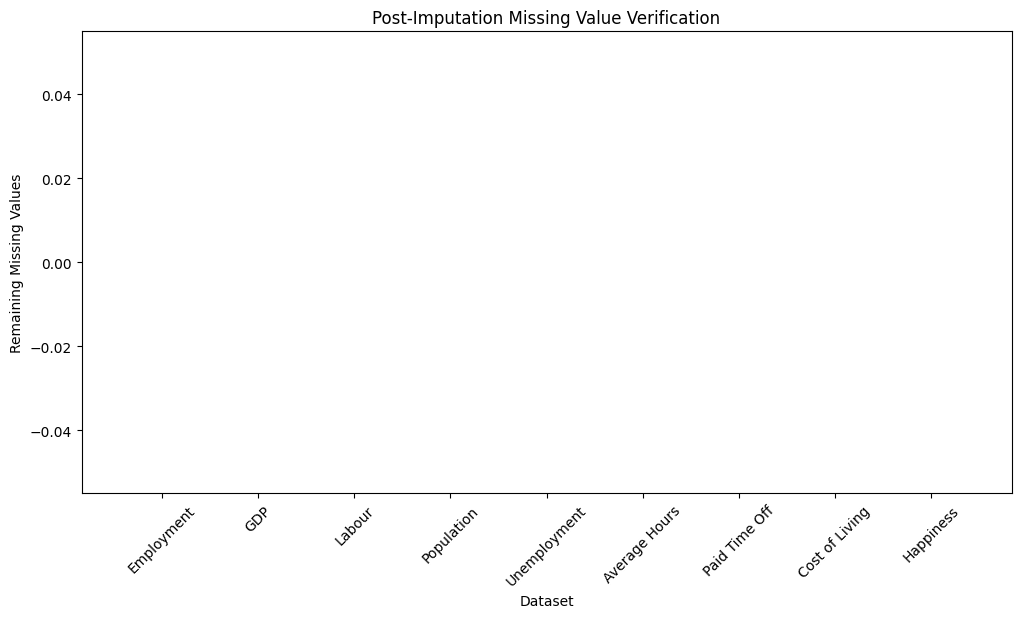

In [21]:
datasets = {
    "Employment": employment,
    "GDP": gdp,
    "Labour": labour,
    "Population": population,
    "Unemployment": unemployment,
    "Average Hours": avg_hrs,
    "Paid Time Off": paid_time_off,
    "Cost of Living": cost_of_living,
    "Happiness": happiness
}

missing_counts = {}

for name, df in datasets.items():
    missing_counts[name] = df.isnull().sum().sum()

plt.figure(figsize=(12, 6))

plt.bar(
    missing_counts.keys(),
    missing_counts.values()
)

plt.ylabel("Remaining Missing Values")
plt.xlabel("Dataset")
plt.title("Post-Imputation Missing Value Verification")

plt.xticks(rotation=45)

plt.show()

---

<h2 id="imputation-of-missing-data-interpretation-of-outliers"
style="
color:#ffffff;
border-bottom:2px solid #555;
padding-bottom:5px;">
3.4 Interpretation of Outliers
</h2>

imputation-of-missing-data-outlier-detection-and-treatment
Visual outlier inspection was conducted using boxplots for each numeric indicator independently. This allowed variables with substantially different scales to be analysed more accurately without distortion from large-value indicators such as GDP per capita or income.

The boxplots revealed the presence of several outliers across the three thematic dimensions of the ICAI framework.

---

<h3 id="imputation-of-missing-data-interpretation-of-outliers-job-market-accessibility-and-growth-indicators"
style="
color:#dddddd;
padding-bottom:3px;">
3.4.1 Job Market Accessibility & Growth Indicators
</h3>

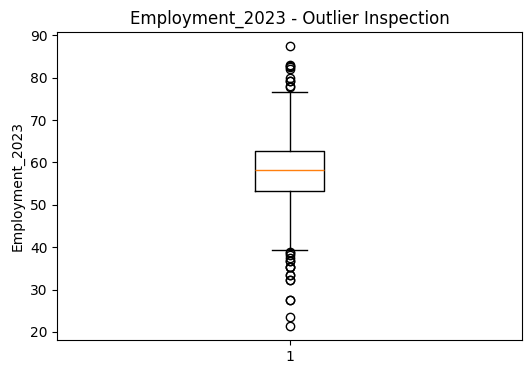

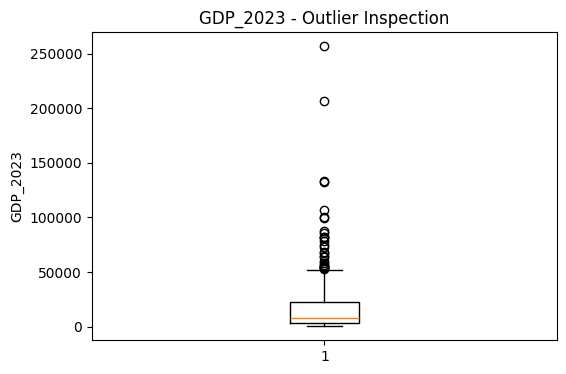

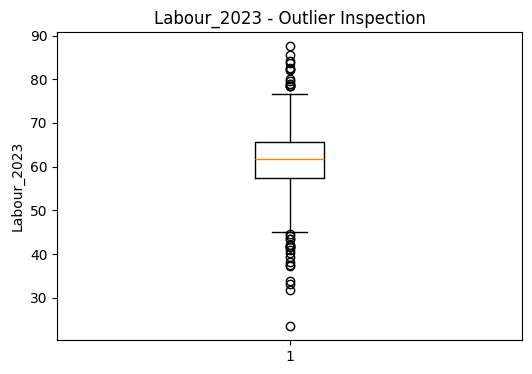

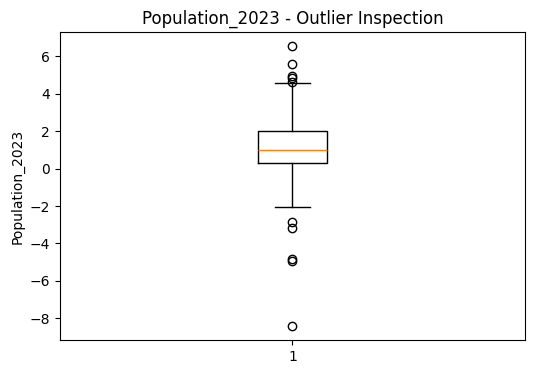

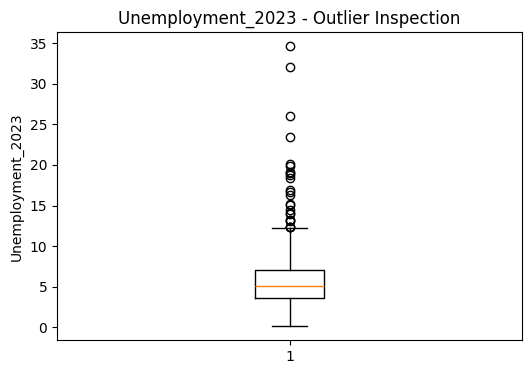

In [22]:
job_market_cols = {
    "Employment_2023": employment["Employment_2023"],
    "GDP_2023": gdp["GDP_2023"],
    "Labour_2023": labour["Labour_2023"],
    "Population_2023": population["Population_2023"],
    "Unemployment_2023": unemployment["Unemployment_2023"]
}

for name, data in job_market_cols.items():
    plt.figure(figsize=(6, 4))
    plt.boxplot(data.dropna())
    plt.title(f"{name} - Outlier Inspection")
    plt.ylabel(name)
    plt.show()

| Indicator | Outlier Observation | Interpretation | Treatment Decision |
|---|---|---|---|
| Employment_2023 | Several lower-end and upper-end outliers identified | Lower outliers likely represent weak labour market participation or economic instability, while upper outliers indicate exceptionally high employment accessibility | Retained as genuine international labour market variation |
| GDP_2023 | Large number of extreme upper outliers | Reflects major income disparities, wealthy microstates, resource-rich economies, and naturally right-skewed economic distributions | Retained as valid economic differences rather than data errors |
| Labour_2023 | Moderate outliers at both lower and upper ranges | Indicates demographic and cultural differences in workforce participation between countries | Retained due to genuine labour participation variation |
| Population_2023 | Positive and negative outliers observed | Negative outliers represent population decline, while positive outliers indicate rapidly growing populations | Retained as valid demographic conditions |
| Unemployment_2023 | Several high-end outliers observed | Likely linked to economic crises, political instability, structural labour market weakness, or post-pandemic recovery difficulties | Retained as meaningful macroeconomic variation |

---

<h3 id="imputation-of-missing-data-interpretation-of-outliers-work-conditions-and-benefits-indicators"
style="
color:#dddddd;
padding-bottom:3px;">
3.4.2 Work Conditions & Benefits Indicators
</h3>

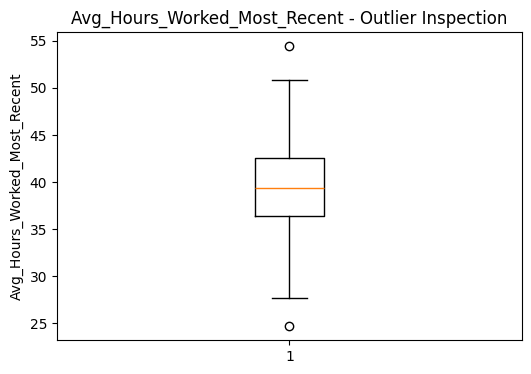

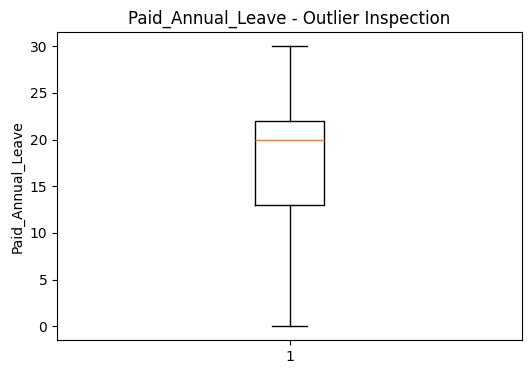

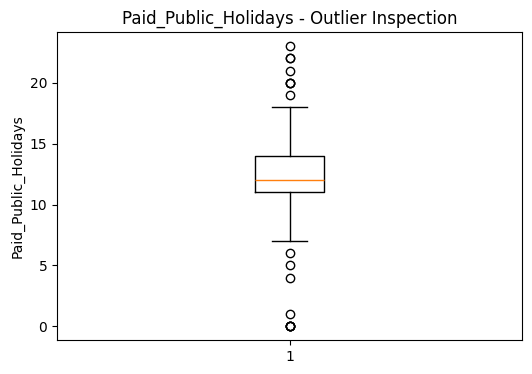

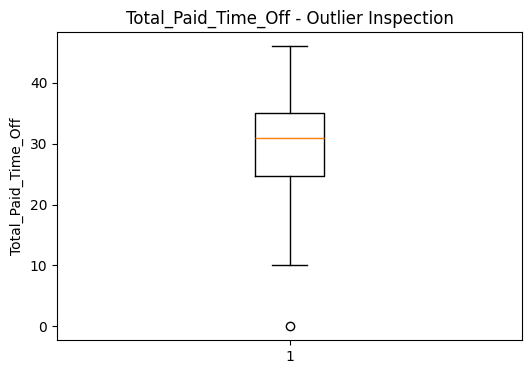

In [23]:
work_cols = {
    "Avg_Hours_Worked_Most_Recent":
        avg_hrs["Avg_Hours_Worked_Most_Recent"],
    "Paid_Annual_Leave":
        paid_time_off["Paid_Annual_Leave"],
    "Paid_Public_Holidays":
        paid_time_off["Paid_Public_Holidays"],
    "Total_Paid_Time_Off":
        paid_time_off["Total_Paid_Time_Off"]
}

for name, data in work_cols.items():
    plt.figure(figsize=(6, 4))
    plt.boxplot(data.dropna())
    plt.title(f"{name} - Outlier Inspection")
    plt.ylabel(name)
    plt.show()

| Indicator | Outlier Observation | Interpretation | Treatment Decision |
|---|---|---|---|
| Avg_Hours_Worked_Most_Recent | Small number of lower and upper outliers | Higher values may indicate overtime-heavy work cultures, while lower values may reflect stronger work-life balance systems | Retained as genuine working-condition differences |
| Paid_Annual_Leave | Minimal outlier behaviour | Leave entitlement policies appeared relatively stable internationally | No treatment required |
| Paid_Public_Holidays | Several lower and upper outliers | Reflects variation in national public holiday systems | Retained as valid policy differences |
| Total_Paid_Time_Off | One notable lower outlier near zero | Likely represents countries with limited formal leave protections | Retained as meaningful labour policy variation |

---

<h3 id="imputation-of-missing-data-interpretation-of-outliers-living-reality-and-social-environment-indicators"
style="
color:#dddddd;
padding-bottom:3px;">
3.4.3 Living Reality & Social Environment Indicators

</h3>

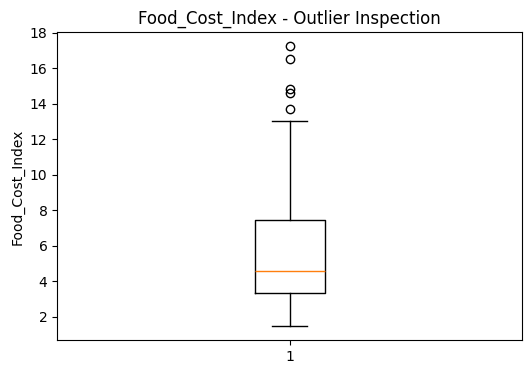

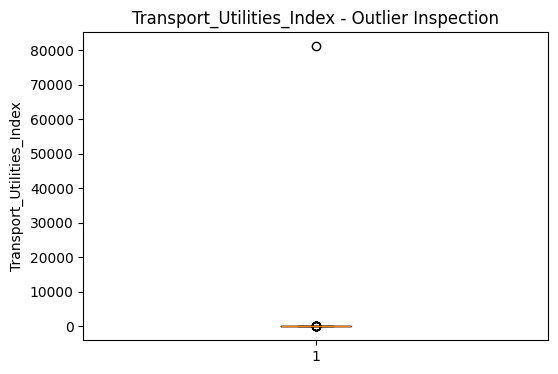

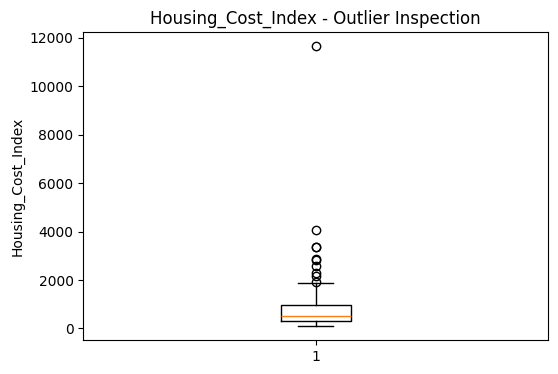

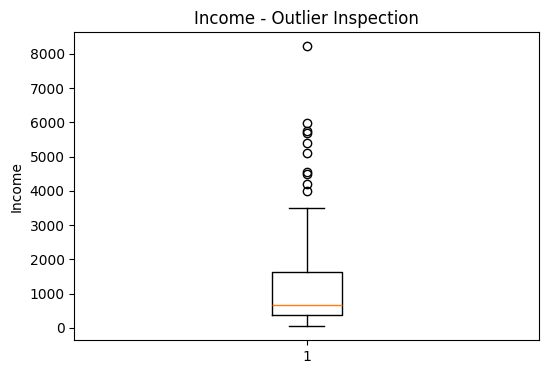

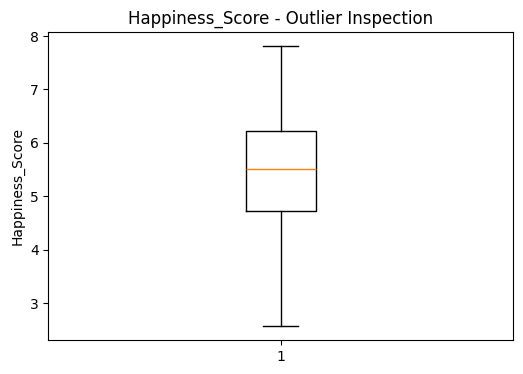

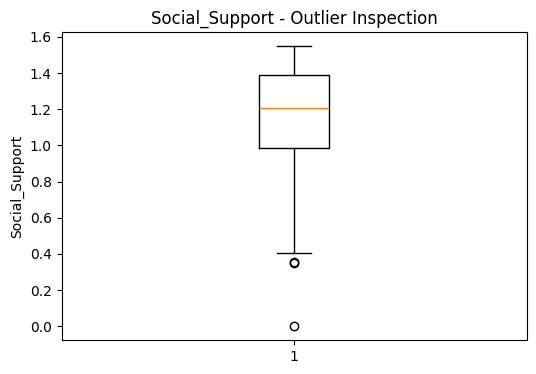

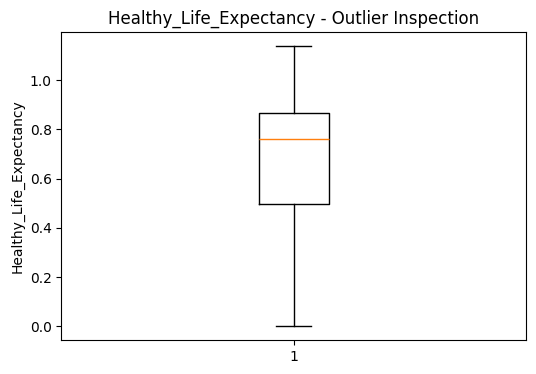

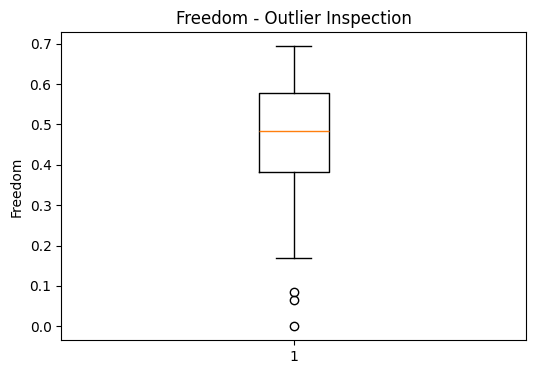

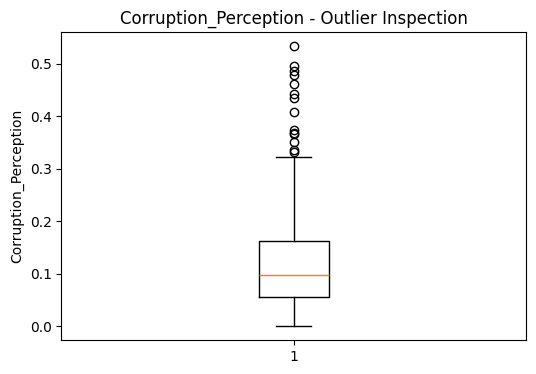

In [24]:
living_cols = {
    "Food_Cost_Index":
        cost_of_living["Food_Cost_Index"],
    "Transport_Utilities_Index":
        cost_of_living["Transport_Utilities_Index"],
    "Housing_Cost_Index":
        cost_of_living["Housing_Cost_Index"],
    "Income":
        cost_of_living["Income"],
    "Happiness_Score":
        happiness["Happiness_Score"],
    "Social_Support":
        happiness["Social_Support"],
    "Healthy_Life_Expectancy":
        happiness["Healthy_Life_Expectancy"],
    "Freedom":
        happiness["Freedom"],
    "Corruption_Perception":
        happiness["Corruption_Perception"]
}

for name, data in living_cols.items():
    plt.figure(figsize=(6, 4))
    plt.boxplot(data.dropna())
    plt.title(f"{name} - Outlier Inspection")
    plt.ylabel(name)
    plt.show()

| Indicator | Outlier Observation | Interpretation | Treatment Decision |
|---|---|---|---|
| Food_Cost_Index | Moderate upper-end outliers identified | Indicates countries or regions with exceptionally high food costs | Retained as real living-cost variation |
| Transport_Utilities_Index | One extremely large upper outlier identified | May reflect highly expensive utility environments, city-level anomalies, or inherited source irregularities | May require additional robustness treatment later |
| Housing_Cost_Index | Several strong upper-end outliers | Reflects major international housing market differences, particularly in urbanised or high-income countries | Retained as structurally valid economic variation |
| Income | Strong upper-tail outlier behaviour | Reflects international wage inequality and salary variation | Retained as genuine economic differences |
| Happiness_Score | Relatively stable distribution with minimal outliers | Suggests broadly consistent international wellbeing distribution | No major treatment required |
| Social_Support | Small number of lower-end outliers | May indicate weaker welfare systems or lower social cohesion | Retained as meaningful societal variation |
| Healthy_Life_Expectancy | Relatively stable with limited extreme values | Reflects moderate international healthcare and wellbeing variation | No major treatment required |
| Freedom | Small number of lower-end outliers | Likely reflects weaker civil liberties or restricted personal freedoms | Retained as valid governance-related variation |
| Corruption_Perception | Several upper-end outliers observed | Indicates stronger perceptions of corruption differences between countries | Retained as meaningful governance variation |

<h1 id="multivariate-analysis"
style="
font-weight:bold;
color:#ffffff;
border-bottom:3px solid #4CAF50;
padding-bottom:8px;
">
4. Multivariate Analysis
</h1>

Following data cleaning, missing-value handling, logical validation, and outlier inspection, multivariate analysis was conducted to examine the statistical structure of the ICAI datasets.

The purpose of this section is to:

<ul>
<li>Analyse relationships between indicators</li>
<li>Identify multicollinearity</li>
<li>Assess whether variables measure overlapping concepts</li>
<li>Compare the statistical structure of the data against the theoretical ICAI framework</li>
<li>Identify groups of statistically similar countries</li>
<li>Guide later methodological decisions before normalisation, weighting, and aggregation</li>
</ul>

Importantly, variables were not removed automatically simply because they were correlated. In composite index construction, correlated indicators may still provide meaningful information because they often represent different aspects of the same broader concept.

For example:

<ul>
<li>Employment and labour-force participation both relate to labour-market accessibility</li>
<li>Paid annual leave and public holidays both relate to worker benefits</li>
<li>Income and living costs both influence practical living standards</li>
</ul>

Therefore, the analysis focused on identifying and understanding relationships rather than immediately excluding variables. A variable would only be considered for exclusion if it was both statistically redundant and conceptually duplicative.

The following multivariate methods were applied:

<ul>
<li>Correlation Analysis</li>
<li>Variance Inflation Factor (VIF) Analysis</li>
<li>Principal Component Analysis (PCA)</li>
<li>Cluster Analysis</li>
</ul>

---


<h2 id="multivariate-analysis-preparing-thematic-analysis-dataframes"
style="
color:#ffffff;
border-bottom:2px solid #555;
padding-bottom:5px;">
4.0 Preparing Thematic Analysis Dataframes
</h2>

Before performing multivariate analysis, the indicators were grouped into the three thematic dimensions of the ICAI framework.


In [28]:
job_market_analysis = pd.concat([
    employment["Employment_2023"],
    gdp["GDP_2023"],
    labour["Labour_2023"],
    population["Population_2023"],
    unemployment["Unemployment_2023"]
], axis=1)

work_conditions_analysis = pd.concat([
    avg_hrs["Avg_Hours_Worked_Most_Recent"],
    paid_time_off[[
        "Paid_Annual_Leave",
        "Paid_Public_Holidays",
        "Total_Paid_Time_Off"
    ]]
], axis=1)

living_analysis = pd.concat([
    cost_of_living[[
        "Food_Cost_Index",
        "Transport_Utilities_Index",
        "Housing_Cost_Index",
        "Income"
    ]],
    happiness[[
        "Happiness_Score",
        "Social_Support",
        "Healthy_Life_Expectancy",
        "Freedom",
        "Corruption_Perception"
    ]]
], axis=1)

These separate dataframes allow each ICAI sub-index dimension to be analysed independently before later normalisation and aggregation.

---

<h2 id="multivariate-analysis-correlation-analysis"
style="
color:#ffffff;
border-bottom:2px solid #555;
padding-bottom:5px;">
4.1 Correlation Analysis
</h2>

Correlation analysis was used to examine the strength and direction of relationships between indicators.

Pearson correlation coefficients were used because the analytical variables are continuous numeric indicators.

Correlation values range from:

<ul>
<li><code>-1</code>: strong negative relationship</li>
<li><code>0</code>: no linear relationship</li>
<li><code>1</code>: strong positive relationship</li>
</ul>

Stronger absolute correlation values indicate stronger linear relationships between variables.

Correlation analysis is particularly important in composite index construction because very strong relationships between indicators may suggest potential multicollinearity or overlapping concepts.

However, strong correlations do not automatically justify removing variables from the ICAI framework, as multiple indicators may still capture different conceptual dimensions despite statistical similarity.

---

<h3 id="multivariate-analysis-correlation-analysis-job-market-correlation-analysis"
style="
color:#dddddd;
padding-bottom:3px;">
4.1.1 Job Market Correlation Analysis
</h3>

,Employment_2023,GDP_2023,Labour_2023,Population_2023,Unemployment_2023
Employment_2023,1.000000,0.120636,0.971854,0.097723,-0.625246
GDP_2023,0.120636,1.000000,0.102866,-0.045545,-0.138303
Labour_2023,0.971854,0.102866,1.000000,0.099356,-0.430756
Population_2023,0.097723,-0.045545,0.099356,1.000000,0.003939
Unemployment_2023,-0.625246,-0.138303,-0.430756,0.003939,1.000000


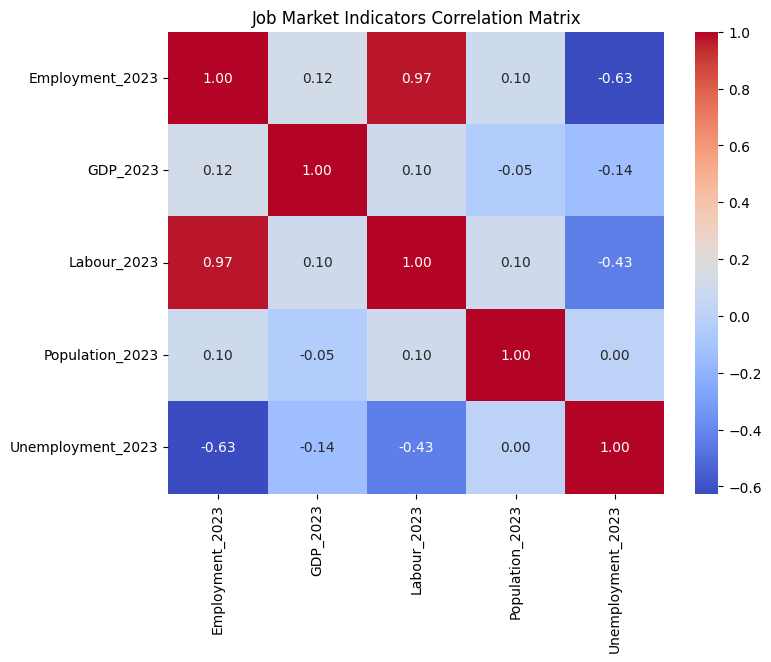

In [31]:
job_market_corr = job_market_analysis.corr()

display(job_market_corr)

plt.figure(figsize=(8, 6))

sns.heatmap(
    job_market_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Job Market Indicators Correlation Matrix")
plt.show()

Interpretation focused particularly on relationships involving:

<ul>
<li>Employment vs Labour Force Participation</li>
<li>Employment vs Unemployment</li>
<li>GDP vs labour-market indicators</li>
<li>Population growth vs other job-market indicators</li>
</ul>

The strongest relationship observed was between <code>Employment_2023</code> and <code>Labour_2023</code> with a correlation coefficient of approximately <code>0.97</code>. This indicates very strong positive multicollinearity between both labour-market participation indicators. The relationship was expected because both variables measure workforce engagement and labour-market accessibility.

A moderately strong negative relationship was observed between <code>Employment_2023</code> and <code>Unemployment_2023</code> with a correlation coefficient of approximately <code>-0.63</code>. This reflects the conceptual opposition between employment availability and unemployment levels.

<code>Labour_2023</code> also showed a moderate negative relationship with <code>Unemployment_2023</code> at approximately <code>-0.43</code>, further supporting the consistency of the labour-market structure within the dataset.

GDP per capita displayed relatively weak correlations with most labour-market variables, suggesting that national economic output alone does not fully determine employment participation or unemployment outcomes across countries.

Population growth exhibited almost no meaningful linear relationship with the remaining job-market indicators, indicating that demographic expansion behaves relatively independently from labour-market performance within the dataset.

Although strong multicollinearity exists between employment and labour-force participation, both variables were retained because they still capture different conceptual dimensions of labour-market conditions. Employment reflects realised workforce participation, while labour-force participation reflects broader engagement within the working-age population.

---

<h3 id="multivariate-analysis-correlation-analysis-work-conditions-correlation-analysis"
style="
color:#dddddd;
padding-bottom:3px;">
4.1.2 Work Conditions Correlation Analysis
</h3>

,Avg_Hours_Worked_Most_Recent,Paid_Annual_Leave,Paid_Public_Holidays,Total_Paid_Time_Off
Avg_Hours_Worked_Most_Recent,1.000000,0.045935,-0.148604,-0.037026
Paid_Annual_Leave,0.045935,1.000000,0.047831,0.858118
Paid_Public_Holidays,-0.148604,0.047831,1.000000,0.553909
Total_Paid_Time_Off,-0.037026,0.858118,0.553909,1.000000


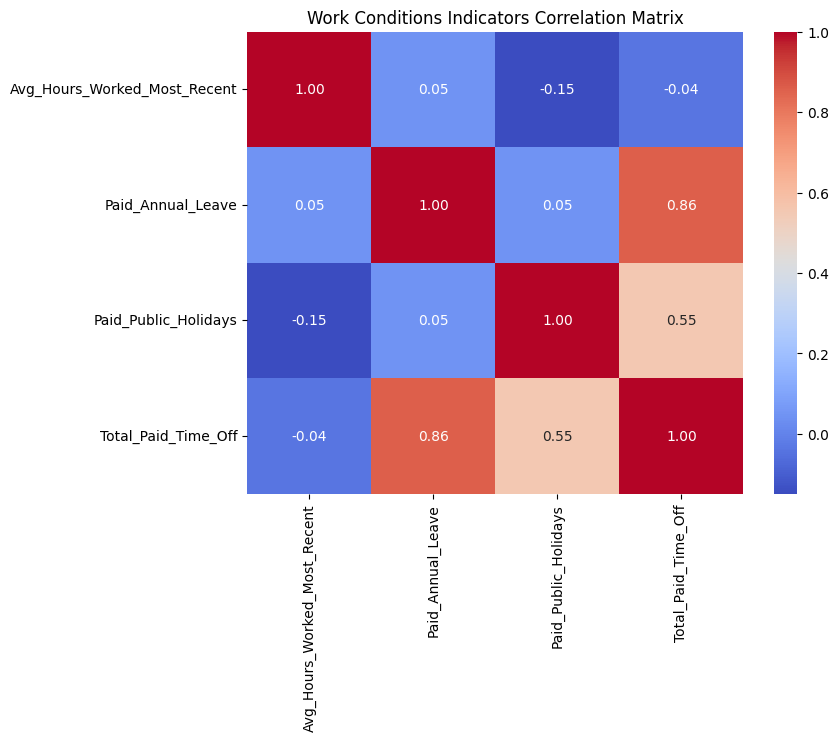

In [32]:
work_conditions_corr = work_conditions_analysis.corr()

display(work_conditions_corr)

plt.figure(figsize=(8, 6))

sns.heatmap(
    work_conditions_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Work Conditions Indicators Correlation Matrix")
plt.show()

Interpretation should focus on:

<ul>
<li>Paid Annual Leave vs Total Paid Time Off</li>
<li>Paid Public Holidays vs Total Paid Time Off</li>
<li>Average Hours Worked vs leave-related indicators</li>
</ul>

A strong relationship between total paid time off and its component variables is expected because total paid time off is directly related to annual leave and public holidays.

---

Interpretation focused particularly on relationships involving:

<ul>
<li>Paid Annual Leave vs Total Paid Time Off</li>
<li>Paid Public Holidays vs Total Paid Time Off</li>
<li>Average Hours Worked vs leave-related indicators</li>
</ul>

The strongest relationship observed was between <code>Paid_Annual_Leave</code> and <code>Total_Paid_Time_Off</code> with a correlation coefficient of approximately <code>0.86</code>. This indicates strong positive multicollinearity, which was expected because total paid time off is partially derived from annual leave allowances.

A moderate positive relationship was also identified between <code>Paid_Public_Holidays</code> and <code>Total_Paid_Time_Off</code> at approximately <code>0.55</code>. This further confirms that countries offering more public holidays generally provide higher overall paid leave entitlements.

<code>Avg_Hours_Worked_Most_Recent</code> displayed very weak correlations with the leave-related indicators, suggesting that average working hours operate relatively independently from statutory leave entitlements across countries.

Although <code>Total_Paid_Time_Off</code> shares strong relationships with its component variables, it was retained because it captures the combined practical effect of worker leave benefits rather than isolated leave components individually.

<h3 id="multivariate-analysis-correlation-analysis-living-reality-correlation-analysis"
style="
color:#dddddd;
padding-bottom:3px;">
4.1.3 Living Reality Correlation Analysis
</h3>

,Food_Cost_Index,Transport_Utilities_Index,Housing_Cost_Index,Income,Happiness_Score,Social_Support,Healthy_Life_Expectancy,Freedom,Corruption_Perception
Food_Cost_Index,1.000000,0.051756,0.557963,0.641971,NaN,NaN,NaN,NaN,NaN
Transport_Utilities_Index,0.051756,1.000000,0.031402,-0.026268,NaN,NaN,NaN,NaN,NaN
Housing_Cost_Index,0.557963,0.031402,1.000000,0.558917,NaN,NaN,NaN,NaN,NaN
Income,0.641971,-0.026268,0.558917,1.000000,NaN,NaN,NaN,NaN,NaN
Happiness_Score,NaN,NaN,NaN,NaN,1.000000,0.765001,0.770316,0.590597,0.418305
Social_Support,NaN,NaN,NaN,NaN,0.765001,1.000000,0.742744,0.478863,0.210530
Healthy_Life_Expectancy,NaN,NaN,NaN,NaN,0.770316,0.742744,1.000000,0.448846,0.353841
Freedom,NaN,NaN,NaN,NaN,0.590597,0.478863,0.448846,1.000000,0.420145
Corruption_Perception,NaN,NaN,NaN,NaN,0.418305,0.210530,0.353841,0.420145,1.000000


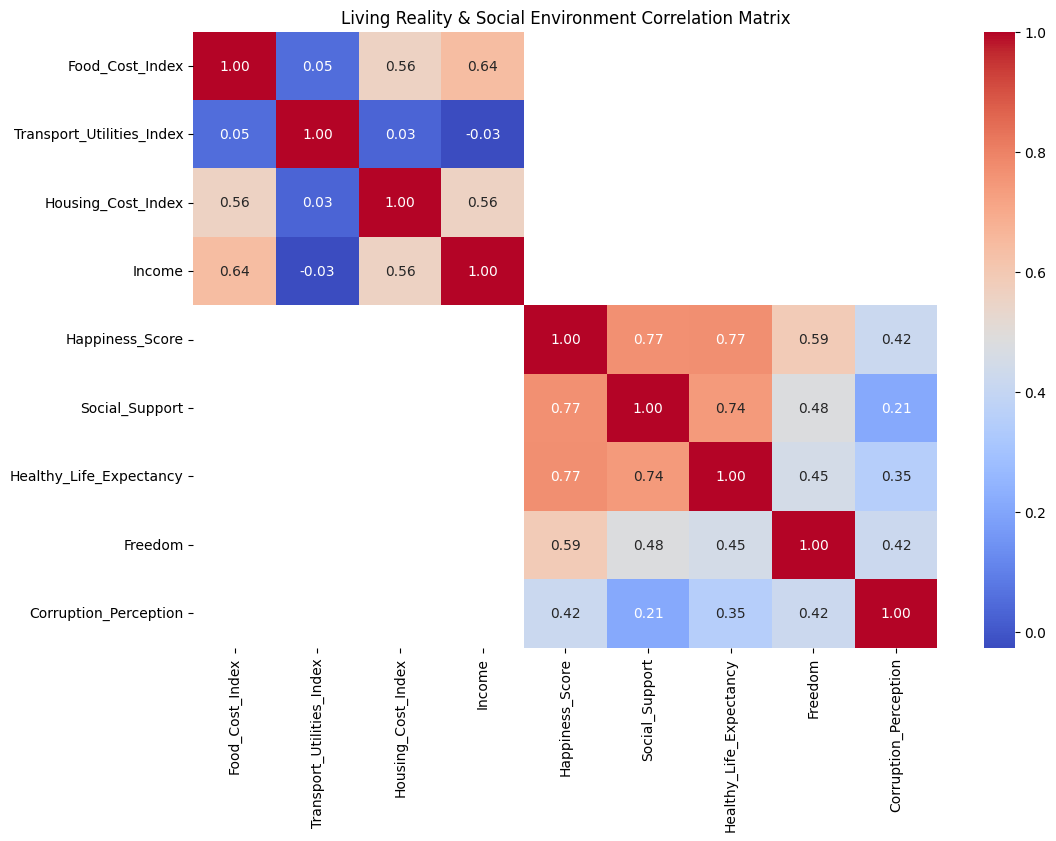

In [33]:
living_corr = living_analysis.corr()

display(living_corr)

plt.figure(figsize=(12, 8))

sns.heatmap(
    living_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Living Reality & Social Environment Correlation Matrix")
plt.show()

Interpretation should focus on:

<ul>
<li>Income vs cost-of-living indicators</li>
<li>Housing cost vs income</li>
<li>Happiness score vs social support</li>
<li>Freedom vs corruption perception</li>
</ul>

These relationships help determine whether living-cost and wellbeing indicators provide distinct information or overlap strongly.

---

Interpretation focused particularly on relationships involving:

<ul>
<li>Income vs cost-of-living indicators</li>
<li>Housing costs vs income</li>
<li>Happiness score vs wellbeing indicators</li>
<li>Freedom vs corruption perception</li>
</ul>

Within the cost-of-living indicators, <code>Income</code> showed moderate positive relationships with both <code>Food_Cost_Index</code> (<code>0.64</code>) and <code>Housing_Cost_Index</code> (<code>0.56</code>). This suggests that countries with higher average incomes also tend to experience higher living costs, particularly in food and housing markets.

<code>Transport_Utilities_Index</code> displayed very weak relationships with the other living-cost indicators, indicating that transportation and utility expenses vary more independently across countries.

Strong positive relationships were identified between the wellbeing indicators:

<ul>
<li><code>Happiness_Score</code> vs <code>Social_Support</code> (<code>0.77</code>)</li>
<li><code>Happiness_Score</code> vs <code>Healthy_Life_Expectancy</code> (<code>0.77</code>)</li>
<li><code>Social_Support</code> vs <code>Healthy_Life_Expectancy</code> (<code>0.74</code>)</li>
</ul>

These findings indicate that countries with stronger social support systems and healthier life conditions generally report higher levels of happiness and wellbeing.

Moderate relationships were also observed between:

<ul>
<li><code>Freedom</code> and <code>Happiness_Score</code> (<code>0.59</code>)</li>
<li><code>Freedom</code> and <code>Corruption_Perception</code> (<code>0.42</code>)</li>
</ul>

This suggests that societal freedom and perceptions of lower corruption contribute positively to overall quality-of-life outcomes.

Although several wellbeing indicators exhibited moderate-to-strong correlations, the variables were retained because each represents a different conceptual dimension of living reality and social environment conditions within the ICAI framework.

<h2 id="multivariate-analysis-variance-inflation-factor-vif-analysis"
style="
color:#ffffff;
border-bottom:2px solid #555;
padding-bottom:5px;">
4.2 Variance Inflation Factor (VIF) Analysis
</h2>

Variance Inflation Factor (VIF) analysis was used to formally assess multicollinearity between indicators within each thematic dataset.

While correlation analysis evaluates pairwise relationships between variables, VIF analysis examines whether a variable can be statistically explained by the combined influence of all other variables within the same dataset.

General interpretation guidelines:

| VIF Value | Interpretation |
|---|---|
| Around 1 | Very low multicollinearity |
| Between 1 - 5 | Acceptable correlation |
| Above 5 | Moderate multicollinearity concern |
| Above 10 | Strong multicollinearity concern |

High VIF values do not automatically justify removing variables from a composite index. Instead, they indicate that variables should be carefully interpreted during later stages such as normalisation, weighting, aggregation, and PCA analysis.

The purpose of this stage was therefore to:
<ul>
<li>Identify potentially redundant indicators</li>
<li>Assess overlap between variables</li>
<li>Support later PCA interpretation</li>
<li>Determine whether any variables were statistically excessive and conceptually duplicative</li>
</ul>

The following helper function was used to calculate VIF values for each thematic analysis dataframe:

In [ ]:
def calculate_vif(df):
    numeric_df = df.select_dtypes(include=["float64", "int64"]).dropna()

    vif_df = pd.DataFrame()
    vif_df["Variable"] = numeric_df.columns
    vif_df["VIF"] = [
        variance_inflation_factor(numeric_df.values, i)
        for i in range(numeric_df.shape[1])
    ]

    return vif_df

The VIF analysis was then conducted separately across:
<ul>
<li>Job Market indicators</li>
<li>Work Conditions indicators</li>
<li>Living Reality & Social Environment indicators</li>
</ul>

This separation allowed multicollinearity to be assessed within each ICAI thematic dimension independently.

---

<h3 id="multivariate-analysis-variance-inflation-factor-vif-analysis-job-market-vif-analysis"
style="
color:#dddddd;
padding-bottom:3px;">
4.2.1 Job Market VIF Analysis
</h3>

In [35]:
job_market_vif = calculate_vif(job_market_analysis)

display(job_market_vif)

,Variable,VIF
0,Employment_2023,5753.592298
1,GDP_2023,1.448349
2,Labour_2023,6312.287697
3,Population_2023,1.594148
4,Unemployment_2023,27.361512


Interpretation focused particularly on variables displaying high multicollinearity.

The VIF results identified extremely high multicollinearity between:

<ul>
<li><code>Employment_2023</code> (<code>VIF ≈ 5754</code>)</li>
<li><code>Labour_2023</code> (<code>VIF ≈ 6313</code>)</li>
</ul>

This behaviour was expected because both variables measure closely related labour-market participation concepts. Countries with high labour-force participation rates generally also exhibit high employment rates, resulting in substantial statistical overlap.

<code>Unemployment_2023</code> also displayed elevated multicollinearity (<code>VIF ≈ 27.36</code>), reflecting its inverse relationship with employment-related indicators.

In contrast:

<ul>
<li><code>GDP_2023</code> (<code>VIF ≈ 1.45</code>)</li>
<li><code>Population_2023</code> (<code>VIF ≈ 1.59</code>)</li>
</ul>

displayed low multicollinearity, suggesting that these variables contribute more independent information within the job-market dimension.

Despite the extremely high VIF values observed for employment and labour-force participation, the variables were retained because they represent conceptually distinct aspects of labour-market performance:

<ul>
<li><code>Employment_2023</code> measures the proportion of employed individuals</li>
<li><code>Labour_2023</code> measures participation within the labour force itself</li>
</ul>

Although Employment_2023 and Labour_2023 exhibit substantial statistical overlap, they were not immediately removed because both variables remain theoretically meaningful within labour-market analysis.

Instead, their redundancy will later be addressed during Principal Component Analysis (PCA), where highly correlated indicators can be combined into lower-dimensional components while preserving most of the original informational variance.

This approach reduces the risk of double-counting labour-market conditions while retaining the conceptual contribution of both indicators within the ICAI framework.

---

<h3 id="multivariate-analysis-variance-inflation-factor-vif-analysis-work-conditions-vif-analysis"
style="
color:#dddddd;
padding-bottom:3px;">
4.2.2 Work Conditions VIF Analysis
</h3>

In [36]:
work_conditions_vif = calculate_vif(work_conditions_analysis)

display(work_conditions_vif)

c:\Users\YCC52\Desktop\Data Analysis & Visualisation\ICAI\venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Variable,VIF
0,Avg_Hours_Worked_Most_Recent,15.865056
1,Paid_Annual_Leave,inf
2,Paid_Public_Holidays,inf
3,Total_Paid_Time_Off,inf


Interpretation focused particularly on variables displaying perfect multicollinearity.

The VIF analysis identified extremely severe multicollinearity within the leave-benefit indicators:

<ul>
<li><code>Paid_Annual_Leave</code> -> <code>VIF = ∞</code></li>
<li><code>Paid_Public_Holidays</code> -> <code>VIF = ∞</code></li>
<li><code>Total_Paid_Time_Off</code> -> <code>VIF = ∞</code></li>
</ul>

This occurred because <code>Total_Paid_Time_Off</code> is directly derived from annual leave and public holidays, resulting in perfect mathematical dependency between the variables.

Unlike the labour-market indicators, this represents structural multicollinearity rather than conceptual overlap alone.

Therefore, <code>Total_Paid_Time_Off</code> was identified as statistically redundant and conceptually duplicative because it does not introduce substantial new information beyond its component variables.

As a result, the variable will be excluded from later PCA, normalisation, and aggregation stages in order to avoid double-counting worker leave entitlements within the ICAI framework.

<code>Avg_Hours_Worked_Most_Recent</code> displayed elevated but finite multicollinearity (<code>VIF ≈ 15.87</code>), suggesting some relationship with leave-related conditions, although it remains conceptually distinct and was therefore retained.

---

<h3 id="multivariate-analysis-variance-inflation-factor-vif-analysis-living-reality-vif-analysis"
style="
color:#dddddd;
padding-bottom:3px;">
4.2.3 Living Reality VIF Analysis
</h3>

In [52]:
living_analysis = pd.merge(
    cost_of_living,
    happiness,
    on="Country Name",
    how="inner"
)

In [53]:
living_analysis = living_analysis[[
    "Food_Cost_Index",
    "Transport_Utilities_Index",
    "Housing_Cost_Index",
    "Income",
    "Happiness_Score",
    "Social_Support",
    "Healthy_Life_Expectancy",
    "Freedom",
    "Corruption_Perception"
]]

In [54]:
living_analysis.info()
living_analysis.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Food_Cost_Index            133 non-null    float64
 1   Transport_Utilities_Index  133 non-null    float64
 2   Housing_Cost_Index         133 non-null    float64
 3   Income                     133 non-null    float64
 4   Happiness_Score            133 non-null    float64
 5   Social_Support             133 non-null    float64
 6   Healthy_Life_Expectancy    133 non-null    float64
 7   Freedom                    133 non-null    float64
 8   Corruption_Perception      133 non-null    float64
dtypes: float64(9)
memory usage: 9.5 KB


Food_Cost_Index              0
Transport_Utilities_Index    0
Housing_Cost_Index           0
Income                       0
Happiness_Score              0
Social_Support               0
Healthy_Life_Expectancy      0
Freedom                      0
Corruption_Perception        0
dtype: int64

In [55]:
living_vif = calculate_vif(living_analysis)

display(living_vif)

,Variable,VIF
0,Food_Cost_Index,21.254683
1,Transport_Utilities_Index,7.606939
2,Housing_Cost_Index,5.032234
3,Income,6.228265
4,Happiness_Score,80.638399
5,Social_Support,54.338201
6,Healthy_Life_Expectancy,28.572784
7,Freedom,20.543961
8,Corruption_Perception,4.743951


Interpretation focused particularly on variables displaying elevated multicollinearity within the Living Reality & Social Environment dimension.

The VIF analysis identified substantial multicollinearity between several wellbeing-related indicators:

<ul>
<li><code>Happiness_Score</code> → <code>VIF ≈ 80.64</code></li>
<li><code>Social_Support</code> → <code>VIF ≈ 54.34</code></li>
<li><code>Healthy_Life_Expectancy</code> → <code>VIF ≈ 28.57</code></li>
<li><code>Freedom</code> → <code>VIF ≈ 20.54</code></li>
</ul>

These elevated VIF values were expected because the variables collectively describe broader quality-of-life and societal wellbeing conditions. Countries with high happiness levels frequently also demonstrate stronger social support systems, healthier life expectancy, and greater societal freedom.

Within the economic living-cost indicators:

<ul>
<li><code>Food_Cost_Index</code> → <code>VIF ≈ 21.25</code></li>
<li><code>Transport_Utilities_Index</code> → <code>VIF ≈ 7.61</code></li>
<li><code>Income</code> → <code>VIF ≈ 6.23</code></li>
<li><code>Housing_Cost_Index</code> → <code>VIF ≈ 5.03</code></li>
</ul>

moderate-to-high multicollinearity was also observed. This reflects the economic reality that countries with higher incomes often experience higher food, transport, and housing costs.

In contrast:

<ul>
<li><code>Corruption_Perception</code> → <code>VIF ≈ 4.74</code></li>
</ul>

displayed comparatively lower multicollinearity, suggesting this variable contribute relatively more independent information within the living reality dimension.

Despite the elevated VIF values observed across several wellbeing indicators, the variables were retained because they represent distinct conceptual dimensions of living standards, social wellbeing, and societal conditions within the ICAI framework.

Rather than removing these indicators immediately, their overlap will later be addressed during PCA analysis, where correlated variables can be compressed into lower-dimensional components while preserving most informational variance and reducing double-counting effects.

---


<h2 id="multivariate-analysis-principal-component-analysis-pca"
style="
color:#ffffff;
border-bottom:2px solid #555;
padding-bottom:5px;">
4.3 Principal Component Analysis (PCA)
</h2>

Principal Component Analysis was used to examine the underlying structure of the indicators and assess whether highly related variables could be represented by broader components.

PCA is useful in composite index development because it can:

<ul>
<li>Identify hidden dimensions in the data</li>
<li>Reduce redundancy between correlated variables</li>
<li>Show how much variance is explained by each component</li>
<li>Support later decisions on index structure</li>
</ul>

In this project, PCA was used as an exploratory validation method rather than as an automatic variable-removal method.


In [64]:
def run_pca(df, title):
    numeric_df = df.select_dtypes(include=["float64", "int64"]).dropna()

    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(numeric_df)

    pca = PCA()
    pca_result = pca.fit_transform(scaled_data)

    explained_variance = pd.DataFrame({
        "Component": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
        "Explained Variance Ratio": pca.explained_variance_ratio_,
        "Cumulative Variance": pca.explained_variance_ratio_.cumsum()
    })

    display(explained_variance)

    plt.figure(figsize=(8, 5))

    # Orange Line -> Individual Explained Variance
    plt.plot(
        explained_variance["Component"],
        explained_variance["Explained Variance Ratio"],
        marker="o",
        label="Explained Variance Ratio"
    )

    # Blue Line -> Cumulative Explained Variance
    plt.plot(
        explained_variance["Component"],
        explained_variance["Cumulative Variance"],
        marker="o",
        label="Cumulative Variance"
    )

    plt.title(f"{title} - PCA Explained Variance")
    plt.xlabel("Principal Components")
    plt.ylabel("Variance")
    plt.ylim(0, 1.05)

    plt.legend()
    plt.grid(True)

    plt.show()

    loadings = pd.DataFrame(
        pca.components_.T,
        columns=[f"PC{i+1}" for i in range(len(numeric_df.columns))],
        index=numeric_df.columns
    )

    display(loadings)

    return explained_variance, loadings

---

<h3 id="multivariate-analysis-principal-component-analysis-pca-job-market-pca"
style="
color:#dddddd;
padding-bottom:3px;">
4.3.1 Job Market PCA
</h3>

,Component,Explained Variance Ratio,Cumulative Variance
0,PC1,0.483503,0.483503
1,PC2,0.211887,0.695391
2,PC3,0.183555,0.878945
3,PC4,0.120733,0.999679
4,PC5,0.000321,1.000000


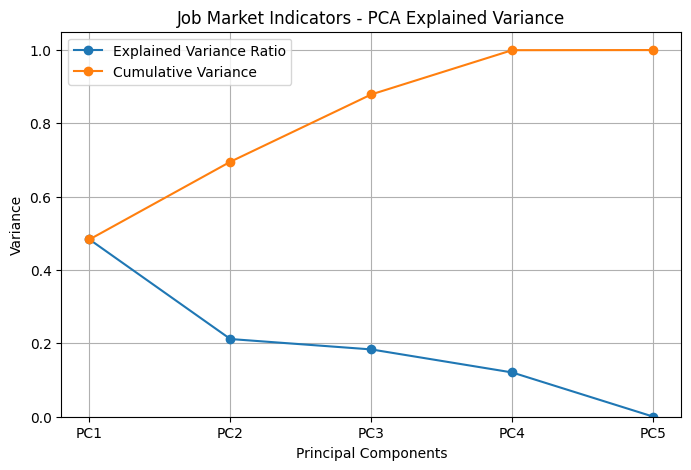

,PC1,PC2,PC3,PC4,PC5
Employment_2023,0.632124,0.060363,-0.092694,0.188156,0.743492
GDP_2023,0.140348,-0.626468,0.760642,0.096228,0.002016
Labour_2023,0.592682,0.100124,-0.084565,0.469292,-0.641340
Population_2023,0.079298,0.756431,0.628806,-0.161349,-0.009605
Unemployment_2023,-0.472399,0.147244,0.101405,0.842063,0.189225


In [65]:
job_market_pca_variance, job_market_pca_loadings = run_pca(
    job_market_analysis,
    "Job Market Indicators"
)

#### Explained Variance & Cumulative Variance

<ul>
<li>The <strong>orange line</strong> represents the variance explained by each individual principal component</li>
<li>The <strong>blue line</strong> represents the cumulative variance retained as additional components are added together</li>
</ul>

Key findings:

| Component | Explained Variance |
|---|---|
| PC1 | 48.35% |
| PC2 | 21.19% |
| PC3 | 18.36% |
| PC4 | 12.07% |
| PC5 | ~0% |

The cumulative variance shows:
<ul>
<li>PC1 alone explains approximately 48% of the dataset variance</li>
<li>PC1-PC3 explain approximately 88% of total variance</li>
<li>Almost all variance is retained by PC4</li>
</ul>

This indicates that several labour-market indicators overlap statistically and can be represented through a smaller number of broader dimensions.

---

#### PCA Loadings Interpretation

The PCA loadings matrix identifies which variables contribute most strongly to each component.

Main observations:

<ul>
<li><code>Employment_2023</code> and <code>Labour_2023</code> load strongly onto PC1</li>
<li><code>Unemployment_2023</code> loads negatively onto PC1</li>
<li><code>Population_2023</code> contributes strongly to PC2</li>
<li><code>GDP_2023</code> contributes strongly to PC3</li>

</ul>

This suggests:

<ul>
<li>Employment and labour-force participation measure a similar labour-market participation dimension</li>
<li>Unemployment behaves inversely as expected</li>
<li>GDP captures a separate economic-performance dimension</li>
<li>Population growth behaves relatively independently from the core labour indicators</li>
</ul>

---

#### Overall Interpretation

The PCA results confirm the presence of multicollinearity between some labour-market indicators, particularly employment and labour-force participation.

However, the indicators do not collapse entirely into a single component, meaning they still contribute conceptually distinct information.

Therefore, the variables were retained for later normalisation and aggregation stages rather than automatically removed.

<h3 id="multivariate-analysis-principal-component-analysis-pca-work-conditions-pca"
style="
color:#dddddd;
padding-bottom:3px;">
4.3.2 Work Conditions PCA
</h3>

,Component,Explained Variance Ratio,Cumulative Variance
0,PC1,0.498973,0.498973
1,PC2,0.288324,0.787297
2,PC3,0.212703,1.000000
3,PC4,0.000000,1.000000


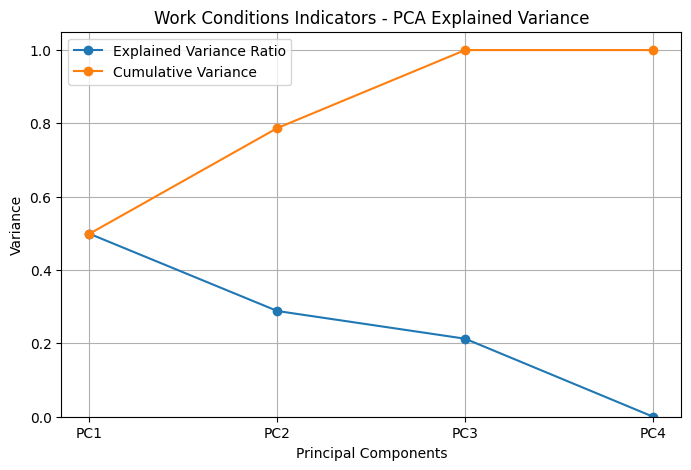

,PC1,PC2,PC3,PC4
Avg_Hours_Worked_Most_Recent,-0.052841,0.694722,0.717335,4.064340e-18
Paid_Annual_Leave,0.603407,0.392332,-0.335515,-6.077874e-01
Paid_Public_Holidays,0.364406,-0.602232,0.610090,-3.637519e-01
Total_Paid_Time_Off,0.707330,0.027471,0.025499,7.058888e-01


In [66]:
work_conditions_pca_variance, work_conditions_pca_loadings = run_pca(
    work_conditions_analysis,
    "Work Conditions Indicators"
)

#### Explained Variance & Cumulative Variance

Within the PCA chart:

<ul>
<li>The <strong>blue line</strong> represents the variance explained by each individual principal component</li>
<li>The <strong>orange line</strong> represents the cumulative variance retained as additional components are added together</li>
</ul>

Key findings:

| Component | Explained Variance |
|---|---|
| PC1 | 49.90% |
| PC2 | 28.83% |
| PC3 | 21.27% |
| PC4 | ~0% |

The cumulative variance shows:
<ul>
<li>PC1 alone explains approximately 50% of total variance</li>
<li>PC1-PC2 explain approximately 79% of total variance</li>
<li>Almost all variance is retained by PC3</li>
</ul>

This indicates that the work-condition indicators share overlapping information while still retaining some separate dimensions.

---

#### PCA Loadings Interpretation

The PCA loadings matrix identifies which variables contribute most strongly to each component.

Main observations:

<ul>
<li><code>Paid_Annual_Leave</code> and <code>Total_Paid_Time_Off</code> load strongly onto PC1</li>
<li><code>Avg_Hours_Worked_Most_Recent</code> loads strongly onto PC2 and PC3</li>
<li><code>Paid_Public_Holidays</code> contributes moderately across multiple components</li>
</ul>

This suggests:

<ul>
<li>Paid annual leave and total paid time off measure a highly similar workplace-benefits dimension</li>
<li>Average working hours behaves relatively independently from leave-related indicators</li>
<li>Public holidays contribute additional but partially overlapping information</li>
</ul>

The strong overlap between annual leave and total paid time off is expected because total paid time off is directly calculated using annual leave and public holidays.

---

#### Overall Interpretation

The PCA results confirm strong multicollinearity within the leave-related indicators, particularly between:

<ul>
<li><code>Paid_Annual_Leave</code></li>
<li><code>Total_Paid_Time_Off</code></li>
</ul>

This relationship was expected because total paid time off is directly derived from annual leave and public holidays.

Although all indicators contribute meaningful information regarding worker protections and work-life balance, `Total_Paid_Time_Off` was identified as both statistically redundant and conceptually duplicative.

Therefore, the variable was retained during exploratory multivariate analysis for validation purposes but will be excluded from later normalisation and aggregation stages to avoid double-counting leave-related benefits within the final ICAI framework.

---

<h3 id="multivariate-analysis-principal-component-analysis-pca-living-reality-pca"
style="
color:#dddddd;
padding-bottom:3px;">
4.3.3 Living Reality PCA
</h3>

,Component,Explained Variance Ratio,Cumulative Variance
0,PC1,0.518116,0.518116
1,PC2,0.189967,0.708084
2,PC3,0.100506,0.808590
3,PC4,0.063380,0.871970
4,PC5,0.045032,0.917003
5,PC6,0.025936,0.942939
6,PC7,0.021716,0.964655
7,PC8,0.020299,0.984955
8,PC9,0.015045,1.000000


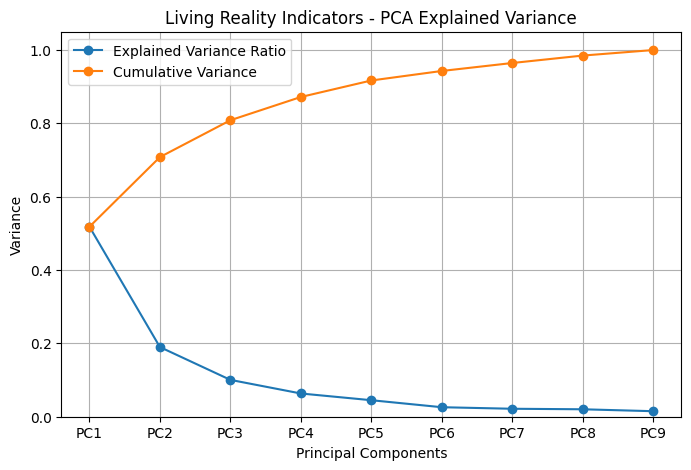

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
Food_Cost_Index,0.374478,0.324304,-0.220100,0.094913,0.047029,-0.123326,0.199487,-0.624363,0.500095
Transport_Utilities_Index,0.209371,0.501704,-0.466987,0.456553,0.085799,-0.042641,-0.295232,0.292607,-0.309804
Housing_Cost_Index,0.301038,0.377478,0.240787,-0.447541,-0.568204,0.120218,-0.391097,0.102833,0.088176
Income,0.406039,0.182889,0.149042,-0.187413,-0.011277,-0.135301,0.709129,0.151709,-0.447251
Happiness_Score,0.394005,-0.282628,-0.132351,0.001112,0.094637,-0.066940,0.084884,0.637305,0.566183
Social_Support,0.330197,-0.355695,-0.383614,-0.094705,-0.062325,0.729531,0.005820,-0.175654,-0.203310
Healthy_Life_Expectancy,0.348735,-0.353215,-0.141758,-0.329161,0.229191,-0.548232,-0.397976,-0.195844,-0.274508
Freedom,0.278844,-0.350802,0.302978,0.637551,-0.503255,-0.152793,-0.035344,-0.119208,-0.094053
Corruption_Perception,0.311124,0.113848,0.613775,0.152793,0.590600,0.299356,-0.224386,-0.037197,-0.004319


In [67]:
living_pca_variance, living_pca_loadings = run_pca(
    living_analysis,
    "Living Reality Indicators"
)

#### Explained Variance & Cumulative Variance

Within the PCA chart:

<ul>
<li>The <strong>blue line</strong> represents the variance explained by each individual principal component</li>
<li>The <strong>orange line</strong> represents the cumulative variance retained as additional components are added together</li>
</ul>

Key findings:

| Component | Explained Variance |
|---|---|
| PC1 | 51.81% |
| PC2 | 18.99% |
| PC3 | 10.05% |
| PC4 | 6.34% |
| Remaining PCs | Smaller contributions |

The cumulative variance shows:
<ul>
<li>PC1 alone explains approximately 52% of total variance</li>
<li>PC1-PC3 explain approximately 81% of total variance</li>
<li>Most dataset variance is retained within the first few components</li>
</ul>

This indicates that several living-reality indicators overlap statistically while still containing additional independent dimensions.

---

#### PCA Loadings Interpretation

The PCA loadings matrix identifies which variables contribute most strongly to each component.

Main observations:

<ul>
<li><code>Food_Cost_Index</code>, <code>Income</code>, and <code>Happiness_Score</code> load strongly onto PC1</li>
<li><code>Corruption_Perception</code> contributes strongly to PC3</li>
<li><code>Freedom</code> contributes strongly to PC4</li>
<li><code>Social_Support</code> contributes strongly to PC6</li>
<li><code>Healthy_Life_Expectancy</code> contributes moderately across multiple components</li>
</ul>

This suggests:

<ul>
<li>Income, living costs, and happiness indicators partially form a shared quality-of-life dimension</li>
<li>Institutional and social indicators such as freedom and corruption contribute separate governance-related dimensions</li>
<li>Social support behaves relatively independently despite moderate correlations with happiness indicators</li>
</ul>

---

#### Overall Interpretation

The PCA results confirm moderate multicollinearity between some quality-of-life indicators, particularly between:

<ul>
<li><code>Income</code></li>
<li><code>Food_Cost_Index</code></li>
<li><code>Housing_Cost_Index</code></li>
<li><code>Happiness_Score</code></li>
</ul>

However, the indicators do not collapse into a single dominant component. Multiple principal components remain necessary to explain the dataset structure.

This indicates that the Living Reality indicators capture several distinct dimensions of living standards, wellbeing, governance, and social conditions.

Therefore, the variables were retained for later normalisation and aggregation stages because they continue to provide conceptually meaningful and statistically distinct information within the ICAI framework.

---

<h2 id="multivariate-analysis-cluster-analysis"
style="
color:#ffffff;
border-bottom:2px solid #555;
padding-bottom:5px;">
4.4 Cluster Analysis
</h2>

Cluster analysis was used to identify groups of statistically similar countries.

Unlike correlation and VIF analysis, which examine relationships between variables, clustering examines similarities between countries.

This supports the specification requirement to identify groups of indicators or countries that are statistically similar.

For clustering, the thematic datasets must include country names. The following example uses the final combined thematic analysis table once available.

In [ ]:
cluster_df = employment[
    ["Country Name", "Employment_2023"]
].merge(
    gdp[["Country Name", "GDP_2023"]],
    on="Country Name"
).merge(
    labour[["Country Name", "Labour_2023"]],
    on="Country Name"
).merge(
    population[["Country Name", "Population_2023"]],
    on="Country Name"
).merge(
    unemployment[["Country Name", "Unemployment_2023"]],
    on="Country Name"
)

cluster_numeric = cluster_df.select_dtypes(include=["float64", "int64"]).dropna()

scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_numeric)

,Employment_2023,GDP_2023,Labour_2023,Population_2023,Unemployment_2023
Cluster,,,,,
0,39.789628,6654.272133,46.216912,1.421834,13.523633
1,68.155383,12972.743251,71.029962,2.422186,4.090435
2,57.275588,25361.806613,60.646140,0.472810,5.458073


To identify a suitable number of clusters, the elbow method was used:


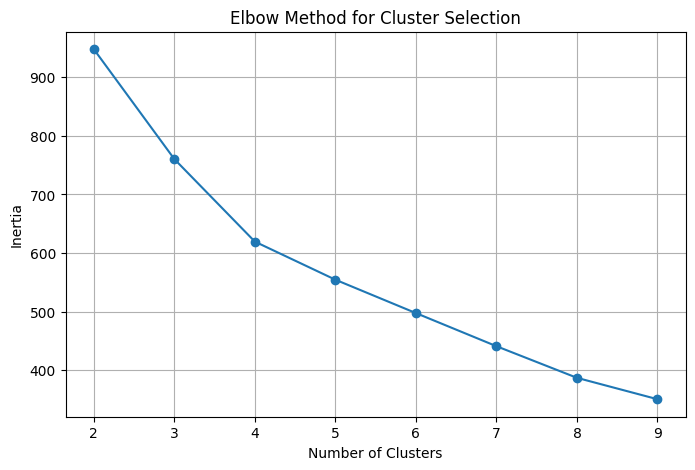

In [72]:
inertia_values = []

k_values = range(2, 10)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(cluster_scaled)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    inertia_values,
    marker="o"
)

plt.title("Elbow Method for Cluster Selection")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

A simple initial clustering model can then be created:


In [76]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(cluster_scaled)

cluster_results = cluster_df.loc[
    cluster_numeric.index
].copy()

cluster_results["Cluster"] = cluster_labels

display(cluster_results.head())

# Check how many countries are in each cluster
cluster_counts = cluster_results["Cluster"].value_counts().sort_index()
display(cluster_counts)

# Show average indicator values for each cluster
cluster_means = cluster_results.groupby("Cluster").mean(numeric_only=True)
display(cluster_means)

# Show example countries from each cluster
for cluster in sorted(cluster_results["Cluster"].unique()):
    print(f"\nCluster {cluster} example countries:")
    display(
        cluster_results[
            cluster_results["Cluster"] == cluster
        ][["Country Name"]].head(10)
    )

,Country Name,Employment_2023,GDP_2023,Labour_2023,Population_2023,Unemployment_2023,Cluster
0,Aruba,58.224674,35718.753119,61.651500,0.045652,5.127920,2
1,Africa Eastern and Southern,63.596635,1571.449189,68.884368,2.519167,7.676548,1
2,Afghanistan,32.323000,413.757895,37.588000,2.135594,14.008000,0
3,Africa Western and Central,70.123283,1841.855064,72.441989,2.386204,3.200801,1
4,Angola,64.369000,2916.136633,74.892000,3.080655,14.051000,1


Cluster
0     40
1     66
2    160
Name: count, dtype: int64

,Employment_2023,GDP_2023,Labour_2023,Population_2023,Unemployment_2023
Cluster,,,,,
0,39.789628,6654.272133,46.216912,1.421834,13.523633
1,68.155383,12972.743251,71.029962,2.422186,4.090435
2,57.275588,25361.806613,60.646140,0.472810,5.458073



Cluster 0 example countries:


,Country Name
2,Afghanistan
7,Arab World
24,Bosnia and Herzegovina
33,Botswana
44,"Congo, Rep."
47,Cabo Verde
56,Djibouti
60,Algeria
67,"Egypt, Arab Rep."
80,Gabon



Cluster 1 example countries:


,Country Name
1,Africa Eastern and Southern
3,Africa Western and Central
4,Angola
8,United Arab Emirates
13,Australia
16,Burundi
18,Benin
19,Burkina Faso
22,Bahrain
23,"Bahamas, The"



Cluster 2 example countries:


,Country Name
0,Aruba
5,Albania
6,Andorra
9,Argentina
10,Armenia
11,American Samoa
12,Antigua and Barbuda
14,Austria
15,Azerbaijan
17,Belgium


The clusters can be visualised using PCA-reduced two-dimensional coordinates:


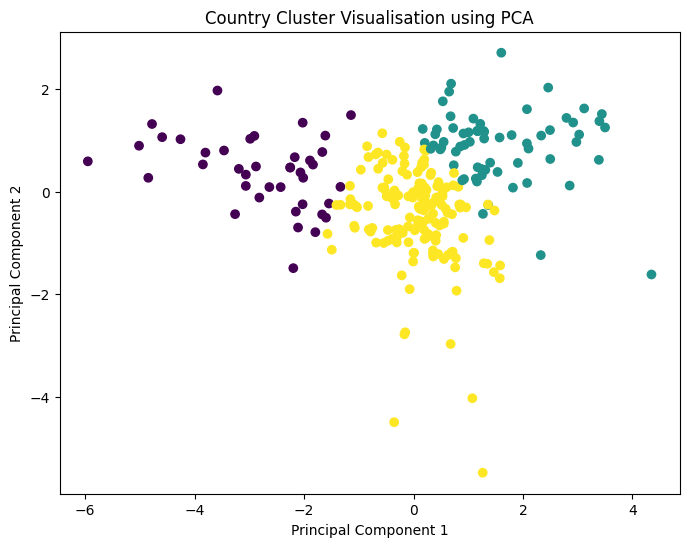

In [74]:
pca_2d = PCA(n_components=2)

cluster_pca = pca_2d.fit_transform(cluster_scaled)

plt.figure(figsize=(8, 6))

plt.scatter(
    cluster_pca[:, 0],
    cluster_pca[:, 1],
    c=cluster_labels
)

plt.title("Country Cluster Visualisation using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

The cluster counts show that the countries were distributed across three statistically distinct labour-market groups:

| Cluster | Number of Countries |
|---|---|
| Cluster 0 | 40 |
| Cluster 1 | 66 |
| Cluster 2 | 160 |

The cluster mean table was then used to identify the overall characteristics of each group.

### Cluster Characteristics

| Cluster | Main Characteristics |
|---|---|
| **Cluster 0** | Lower employment participation, lower labour-force participation, and the highest unemployment levels |
| **Cluster 1** | Highest employment participation, highest labour-force participation, highest GDP per capita, and lowest unemployment |
| **Cluster 2** | Moderate employment and unemployment levels with lower GDP compared to Cluster 1 |

The PCA cluster visualisation further supports these findings.

The scatter plot shows visible separation between the three country groups, indicating that the labour-market indicators successfully capture statistically distinct economic and workforce profiles.

Countries within the same cluster appear closer together because they share similar labour-market characteristics, while countries from different clusters are positioned further apart due to differing economic conditions.

Overall, the cluster analysis demonstrates that the selected labour-market indicators are capable of distinguishing countries according to varying levels of labour-market performance, economic prosperity, and unemployment conditions.

<h2 id="multivariate-analysis-summary"
style="
color:#ffffff;
border-bottom:2px solid #555;
padding-bottom:5px;">
4.5 Multivariate Analysis Summary
</h2>

All in all, the multivariate analysis stage provided a deeper understanding of the statistical structure of the ICAI datasets and the relationships between indicators.

Correlation analysis identified several strong relationships between variables, particularly within the labour-market and work-conditions dimensions. For example:

- Employment and labour-force participation displayed very strong positive correlation
- Total paid time off was strongly related to paid annual leave and public holidays
- Several living-reality indicators, such as income, housing cost, and happiness-related variables, also demonstrated moderate-to-strong relationships

Variance Inflation Factor (VIF) analysis confirmed the presence of multicollinearity within some thematic dimensions. Extremely high VIF values were observed for:

- <code>Employment_2023</code> and <code>Labour_2023</code>
- <code>Paid_Annual_Leave</code> and <code>Total_Paid_Time_Off</code>
- Several happiness and quality-of-life indicators

However, these relationships were expected because many indicators measure related aspects of broader economic, labour-market, and wellbeing conditions.

Principal Component Analysis (PCA) further demonstrated that while some indicators overlap statistically, the datasets do not collapse entirely into a single dimension. Multiple principal components were still required to explain most of the dataset variance, indicating that the indicators continue to provide conceptually meaningful and statistically distinct information.

The PCA loading matrices also showed that:
- labour-market indicators form a shared workforce-participation dimension,
- leave-related variables form a common worker-benefits dimension,
- living-reality indicators capture multiple dimensions of wellbeing, governance, economic conditions, and social support.

Cluster analysis then demonstrated that the selected indicators successfully grouped countries into statistically distinct profiles. The labour-market clustering results revealed separate country groups characterised by differing levels of:
- employment participation,
- GDP per capita,
- labour-force participation,
- and unemployment conditions.

Although multicollinearity was identified in several areas, variables were not automatically removed solely due to statistical correlation. Within composite-index construction, correlated indicators may still contribute meaningful conceptual information if they capture different aspects of the theoretical framework.

One exception was identified within the Work Conditions dimension, where <code>Total_Paid_Time_Off</code> was found to be directly derived from:
- <code>Paid_Annual_Leave</code>
- <code>Paid_Public_Holidays</code>

As a result, this variable was considered statistically redundant and conceptually duplicative, and therefore suitable for removal during later ICAI construction stages.

Overall, the multivariate analysis confirmed that the selected indicators provide a suitable statistical foundation for the ICAI framework while also highlighting areas of overlap that should be carefully considered during later normalisation, weighting, and aggregation stages.

---